# SCT analysis — magnetic_2…5 (FR0)

Исследование связи орбитальной хроматичности, удлинения пути и спиновой когерентности в COSY Infinity для дейтрона.

Задача имеет две части. Сначала по FR0 mapping определяется настройка трёх семейств секступолей, при которой обнуляются $\xi_x$, $\xi_y$ и $\eta_1$. Затем проверяется, что это обнуление действительно меняет продольную динамику и не маскирует проблему в спиновой части.

Тетрадь не запускает COSY: она читает уже рассчитанные артефакты из `dat/` и графики из `plots/`. Это важно: отделены воспроизводимый численный результат, его физическая интерпретация и то, что пока остаётся гипотезой.

Охват:

- mapping, $I^*$, $\Delta\delta_{eq}$, рабочие точки и Twiss-фазы: `magnetic_2`…`magnetic_5`;
- multi-turn и dense spin: пока только пилот `magnetic_2`;
- резонансный scan: расстояния до линий для всех stems, наблюдаемая сила — пока только по dense-трекингу пилота.

## 0. Координаты, величины и границы сравнения

| Символ / поле | Смысл |
|---|---|
| $\mathbf I=(SG_{x1},SG_{x2},SG_{y1})$ | численные коэффициенты трёх семейств секступолей SF1, SF2, SD; без калибровки это не амперы источника |
| $D$ в `TRPRAY` | шестая фазовая координата COSY в `OV 3 3 0`: относительное отклонение импульса/энергии |
| $\Delta\delta_{\rm eq}$ | теоретический сдвиг равновесного относительного импульса из $\xi_{x,y}$, $\eta_1$, $\varepsilon$, $\delta_m$ |
| `mean_D_offset` | $\overline D_i-\overline D_{\rm ref}$ после transient — трекинговый proxy, **не** $\Delta\delta_{\rm eq}$ |
| $C(n)$ | фазовая согласованность $\lvert N^{-1}\sum e^{i\Delta\phi_i}\rvert$ в сохранённые моменты |
| $\Delta\nu_{s,i}$ | относительный spin tune; определяем только при $\Delta n_{\rm save}\le 1/(2|\nu_s|)$ |
| `aliased_phase_slope` | наклон фазы при нарушенном Найквисте — не физический tune |

В COSY `OV 3 2 1` используется для хроматичности: две поперечные степени свободы и параметр $\delta$. `OV 3 3 0` — полное 6D фазовое пространство $(X,A,Y,B,T,D)$; именно в нём выполняются трекинг и спин.

Физическая цепочка здесь такова: бетатронное и дисперсионное удлинение орбиты меняет равновесный импульс частицы, а через $\nu_s=G\gamma$ даёт разброс спиновой фазы. Теоретическая формула и `mean_D_offset` смотрят на разные уровни этой цепочки; совпадение тенденции полезно, но численно они не обязаны совпадать.

In [5]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

STUDY = Path("COSY/sct_study").resolve()
if not STUDY.is_dir():
    STUDY = Path(".").resolve()
sys.path.insert(0, str(STUDY / "py"))
from common import (  # noqa: E402
    DAT_OUT,
    PLOTS,
    delta_eq_theory,
    gamma_beta,
    get_data,
    get_dual_model,
    lattice_length,
    load_config,
    solve_currents,
    stems,
)

cfg = load_config()
STEMS = stems()
g, b = gamma_beta(cfg)
print("stems:", STEMS)
print(f"gamma={g:.6f}, G={cfg['G']}, gammaG={g*cfg['G']:.6f}")
print("dense save every", cfg["tracking"]["save_every_turns_dense"], "turns")


stems: ['magnetic_2', 'magnetic_3', 'magnetic_4', 'magnetic_5']
gamma=1.143914, G=-0.142987, gammaG=-0.163565
dense save every 2 turns


## 1. Mapping и решение $\mathbf I^*$

Для каждой из 125 FR0-точек известны $\xi_x$, $\xi_y$, $\eta_1$ и spin-ответ зондов. В окрестности сетки строится линейная модель

$$
\boldsymbol\xi=
\begin{pmatrix}\xi_x\\\xi_y\\\eta_1\end{pmatrix}
=R_{\rm int}\mathbf I+\boldsymbol\xi_{\rm natural}.
$$

Здесь $\boldsymbol\xi_{\rm natural}$ — значение при выключенных секступолях, а строки $R_{\rm int}$ — отклики трёх величин на три семейства. Искомая настройка является решением

$$
R_{\rm int}\mathbf I^*=-\boldsymbol\xi_{\rm natural}.
$$

`cond(R_int)` характеризует чувствительность этого решения к ошибке mapping: это не вероятность и не процент точности. FR0 box — прямоугольная область реально рассчитанных коэффициентов. Если $I^*$ вне box, используется экстраполяция; поэтому хорошее $R^2$ внутри сетки ещё недостаточно. Для этого и выполнен независимый `validate_Istar.dat` в COSY.

Величина

$$
d_{\min}=\min_k\|\mathbf I^*-\mathbf I_k\|_2
$$

характеризует удалённость от ближайшей FR0-точки. Сравнение сырых $d_{\min}$ между структурами некорректно: шаги scan различны. Ниже показано также $d_{\min}/\|\Delta I\|_2$, то есть расстояние в единицах характерного шага сетки.

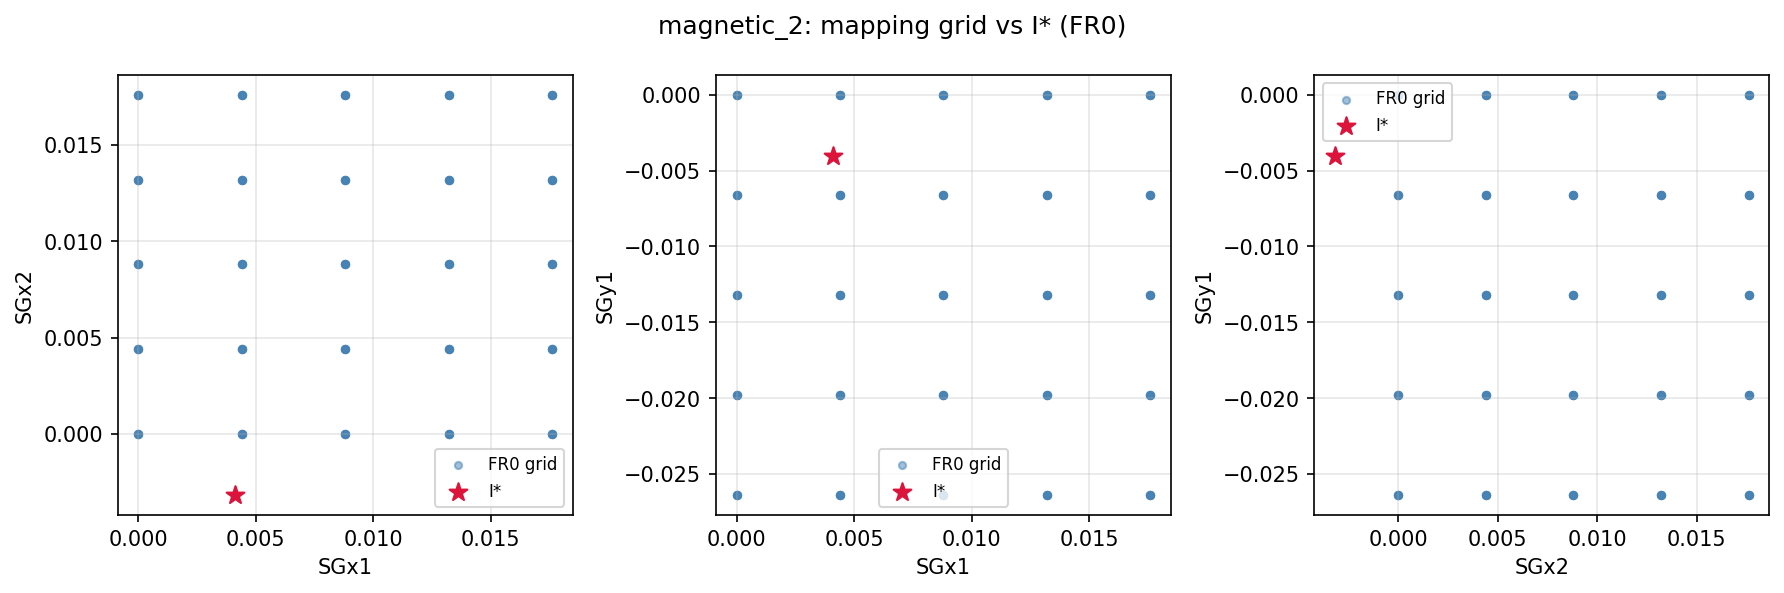

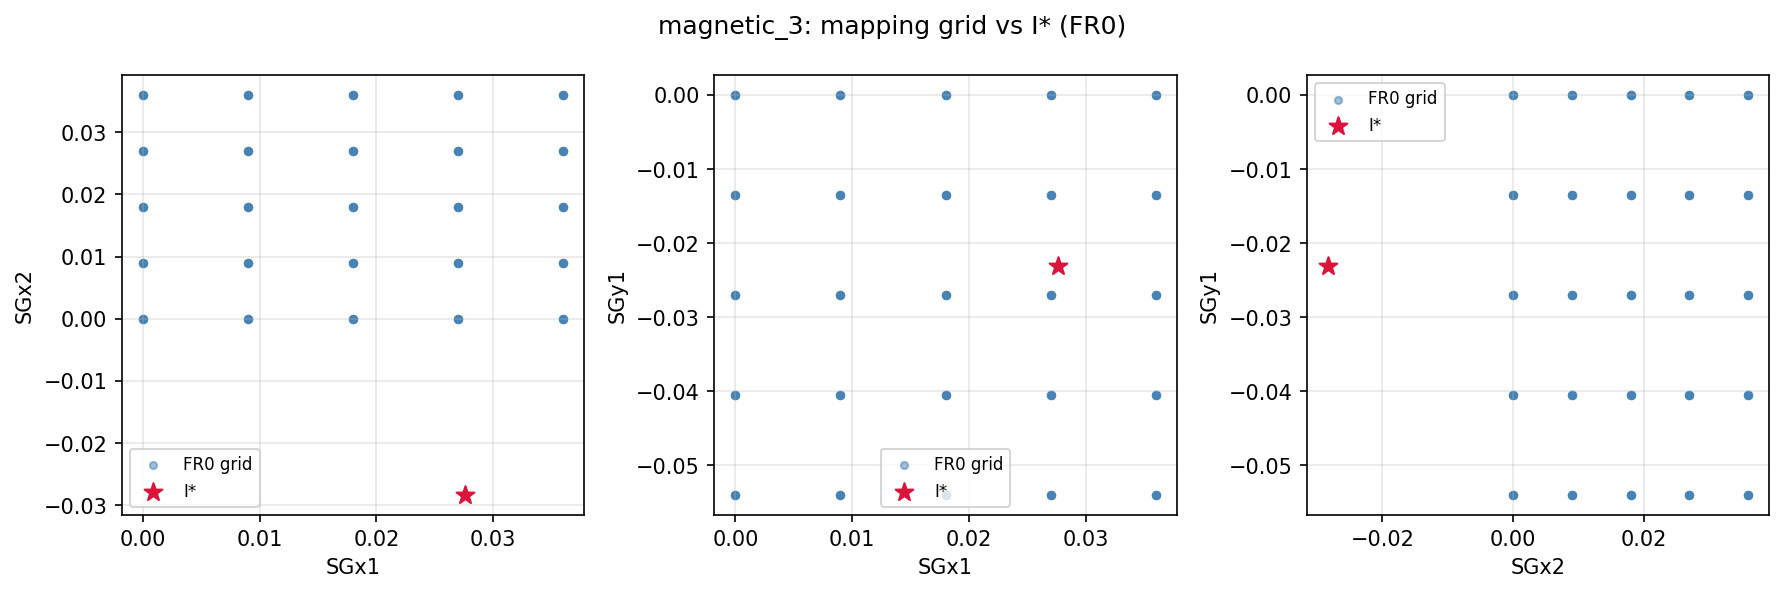

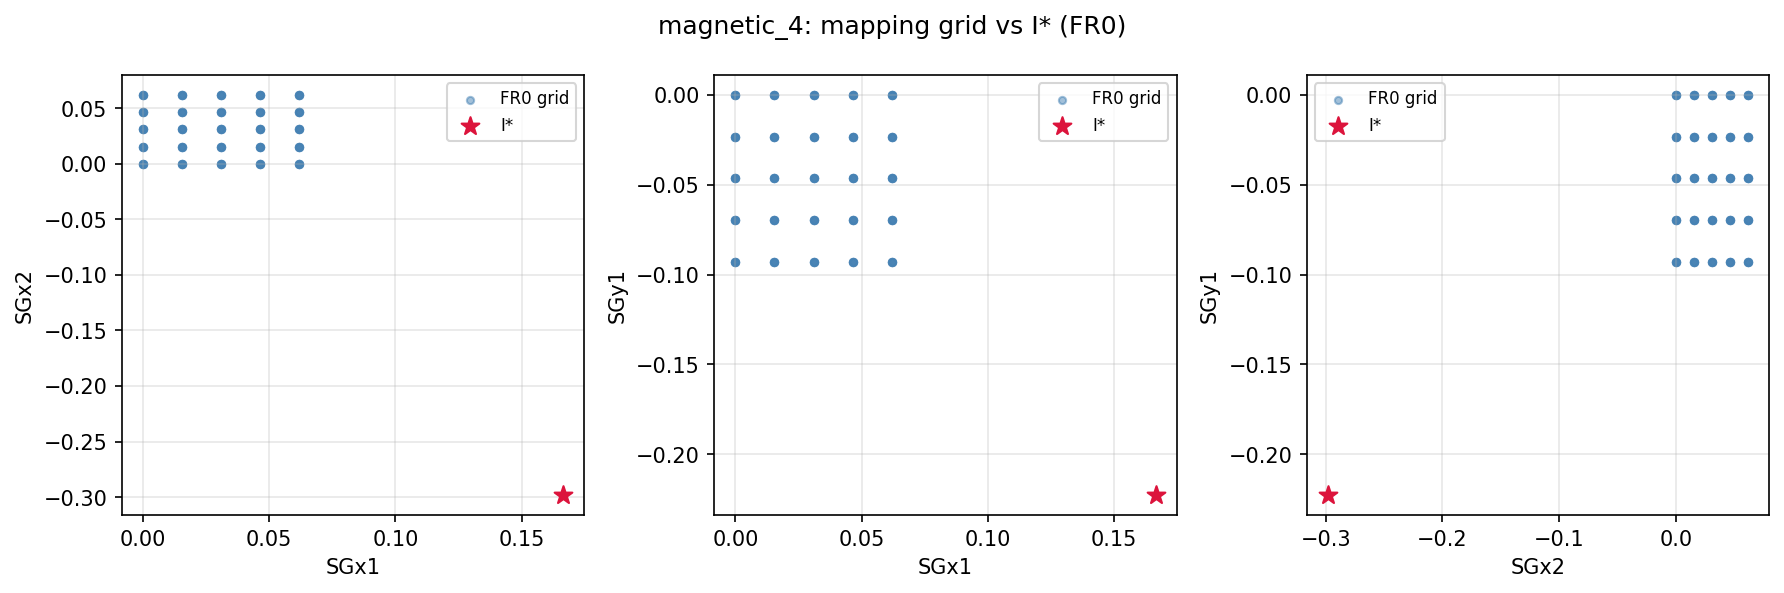

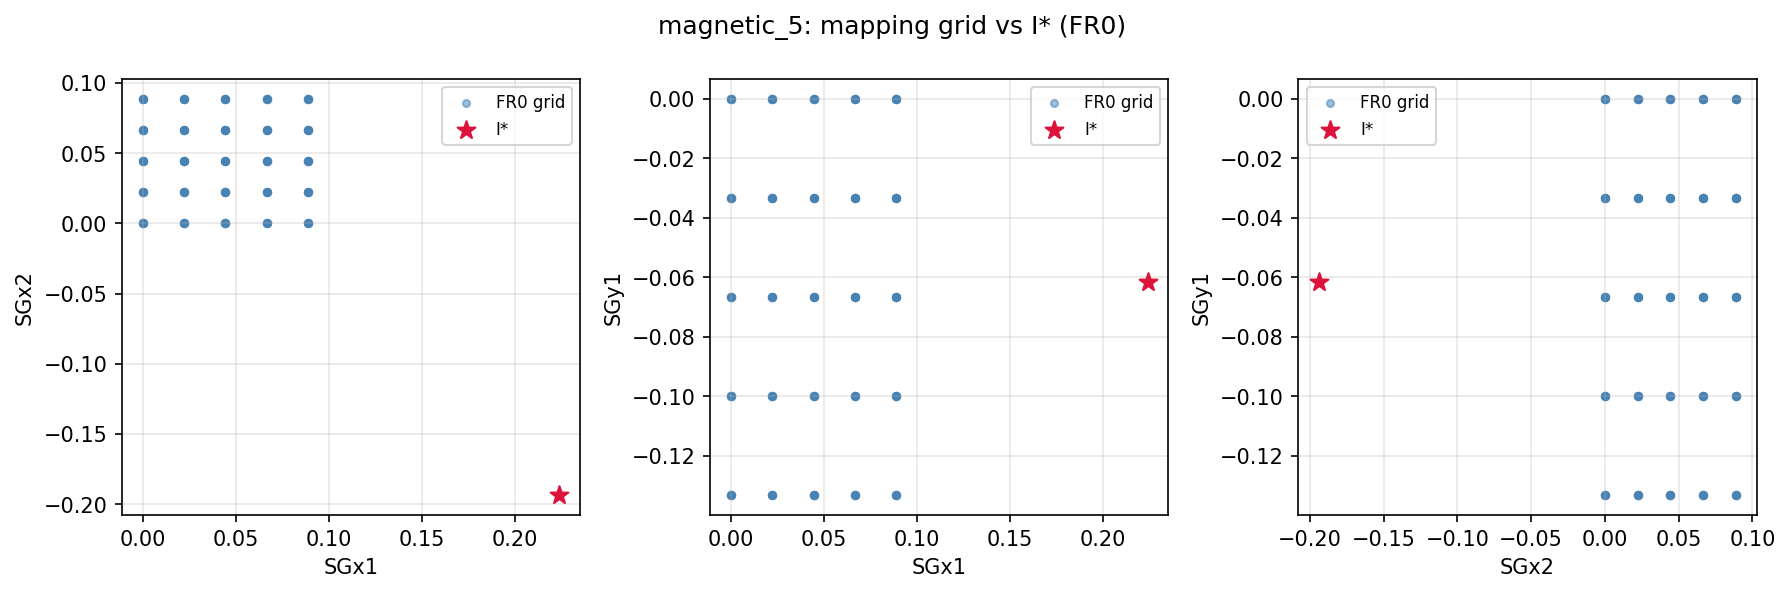

,stem,cond,SGx1*,SGx2*,SGy1*,inside_FR0,d_min,d_norm,chrom_x@I*,chrom_y@I*,eta1@I*
0,magnetic_2,34.538178,0.004111,-0.003184,-0.004031,False,0.004102,0.452181,-0.0,-0.0,-0.0
1,magnetic_3,35.874824,0.027590,-0.028351,-0.023078,False,0.028627,1.542928,-0.0,-0.0,0.0
2,magnetic_4,180.588538,0.166469,-0.298176,-0.222727,False,0.341620,10.703137,-0.0,-0.0,-0.0
3,magnetic_5,69.663430,0.223842,-0.193672,-0.061637,False,0.236156,5.160024,-0.0,-0.0,-0.0


In [6]:
rows = []
for stem in STEMS:
    audit = json.loads((DAT_OUT / stem / "audit.json").read_text(encoding="utf-8"))
    m = audit["model"]
    gr = m["grid_relation"]
    zp = json.loads((DAT_OUT / stem / "zero_point.json").read_text(encoding="utf-8"))
    cosy = zp.get("cosy_validation", {}).get("measured", {})
    rows.append({
        "stem": stem,
        "cond": m["condition_number"],
        "SGx1*": m["I_star"][0],
        "SGx2*": m["I_star"][1],
        "SGy1*": m["I_star"][2],
        "inside_FR0": gr["inside_axis_aligned_box"],
        "d_min": gr["min_distance_to_grid_point"],
        "d_norm": gr.get("min_distance_normalized"),
        "chrom_x@I*": cosy.get("chrom_x"),
        "chrom_y@I*": cosy.get("chrom_y"),
        "eta1@I*": cosy.get("eta1"),
    })
    p = PLOTS / f"{stem}_grid_vs_istar.png"
    if p.is_file():
        display(Image(filename=str(p)))
pd.DataFrame(rows).round(6)


## 2. Какие конфигурации сравниваются; рабочие точки

`tag` — не новая решётка, а набор коэффициентов секступолей внутри одного stem:

- `natural`: $\mathbf I=0$;
- `Istar`: решение задачи $\xi_x=\xi_y=\eta_1=0$;
- `ctrl_xi_x`, `ctrl_xi_y`, `ctrl_eta1`: mapping-точки с большим соответствующим коэффициентом.

Рабочая точка извлекается из one-turn map центральной частицы. В текущей модели $Q_x$, $Q_y$ и $\nu_s$ почти не меняются между tag: секступоли не вносят линейную фокусировку на центральной орбите, а $\gamma G$ фиксирован энергией и магнитным моментом дейтрона. Это ожидаемый sanity check, а не утверждение об одинаковых индивидуальных частотах частиц.

Таблица намеренно содержит одну строку на stem при $I^*$; детальные расстояния до резонансных линий разобраны в §5.

,stem,Qx,Qy,NU_s,gammaG,nearest_dist,nearest_form
0,magnetic_2,0.446284,0.476682,0.163565,-0.163565,0.282719,0*P - Q_x
1,magnetic_3,0.709522,0.688151,0.163565,-0.163565,0.524586,0*P - Q_y
2,magnetic_4,0.928547,0.911708,0.163565,-0.163565,0.748143,0*P - Q_y
3,magnetic_5,0.241657,0.227440,0.163565,-0.163565,0.063875,0*P - Q_y


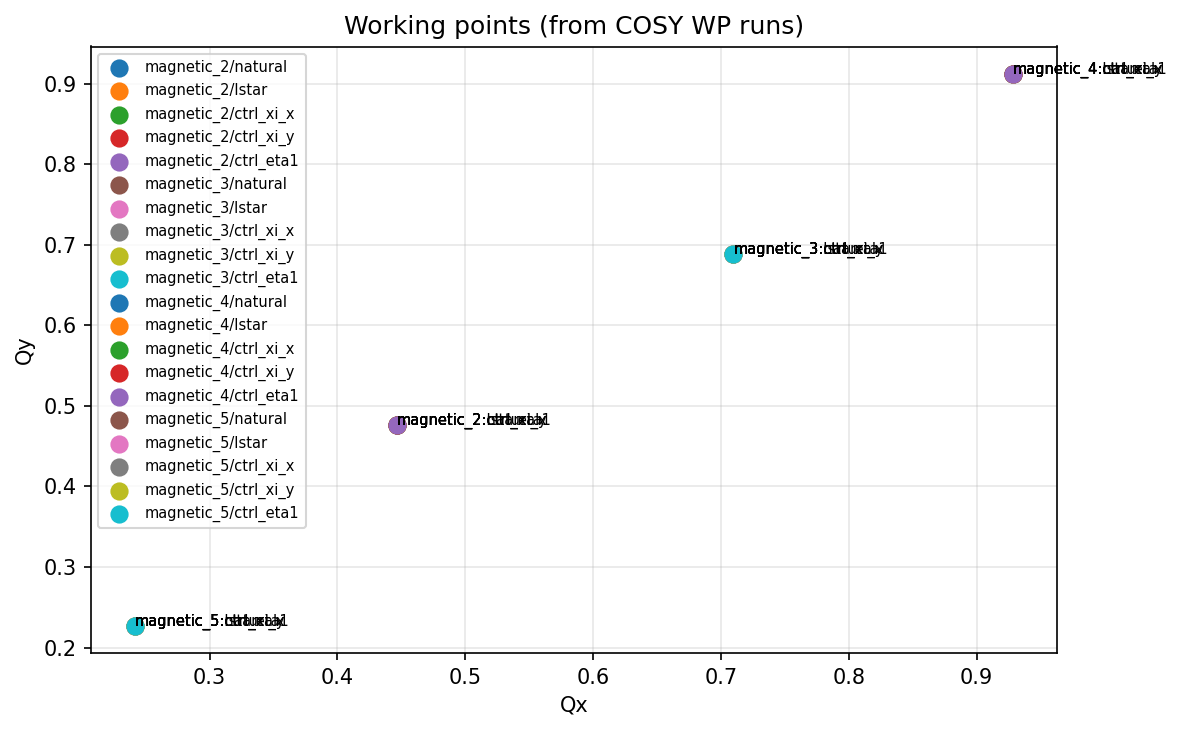

In [7]:
wp_rows = []
for stem in STEMS:
    data = json.loads((DAT_OUT / stem / "working_point.json").read_text(encoding="utf-8"))
    pt = data["points"].get("Istar", {})
    if "Qx" not in pt:
        continue
    nearest = pt.get("nearest_resonances") or []
    wp_rows.append({
        "stem": stem,
        "Qx": pt["Qx"],
        "Qy": pt["Qy"],
        "NU_s": pt["NU_s"],
        "gammaG": pt["gammaG"],
        "nearest_dist": nearest[0]["distance"] if nearest else None,
        "nearest_form": nearest[0]["form"] if nearest else None,
    })
display(pd.DataFrame(wp_rows).round(6))
p = PLOTS / "working_points_summary.png"
if p.is_file():
    display(Image(filename=str(p)))


## 3. Теория $\Delta\delta_{\rm eq}$: от удлинения пути к spin tune

Для bunch с RF условие синхронности требует, чтобы усреднённое время оборота было согласовано с RF. Бетатронные колебания и нелинейный momentum compaction меняют длину траектории; равновесный уровень импульса становится индивидуальным для каждой частицы. В использованном приближении Senichev et al.:

$$
\Delta\delta_{\rm eq}
=\frac{\gamma^{2}}{\gamma^{2}\alpha_{0}-1}
\left[
\frac12\delta_{m}^{2}\eta_{1}
-\frac{\pi}{L}(\varepsilon_x\xi_x+\varepsilon_y\xi_y)
\right].
$$

Первое слагаемое описывает вклад продольного разброса через $\eta_1$, второе — вклад поперечных эмиттансов через хроматичности. Далее разброс $\delta_{\rm eq}$ даёт разброс $\gamma$, а значит и $\nu_s=G\gamma$.

Эта формула не является определением COSY-координаты $D$. В `TRPRAY` мы видим траекторию $D_i(n)$, в то время как формула — усреднённое равновесное смещение в асимптотическом приближении. При $\xi_x=\xi_y=\eta_1=0$ правая часть обнуляется по построению: график, проходящий через ноль, валидирует реализацию формулы, но не заменяет отдельный трекинг.

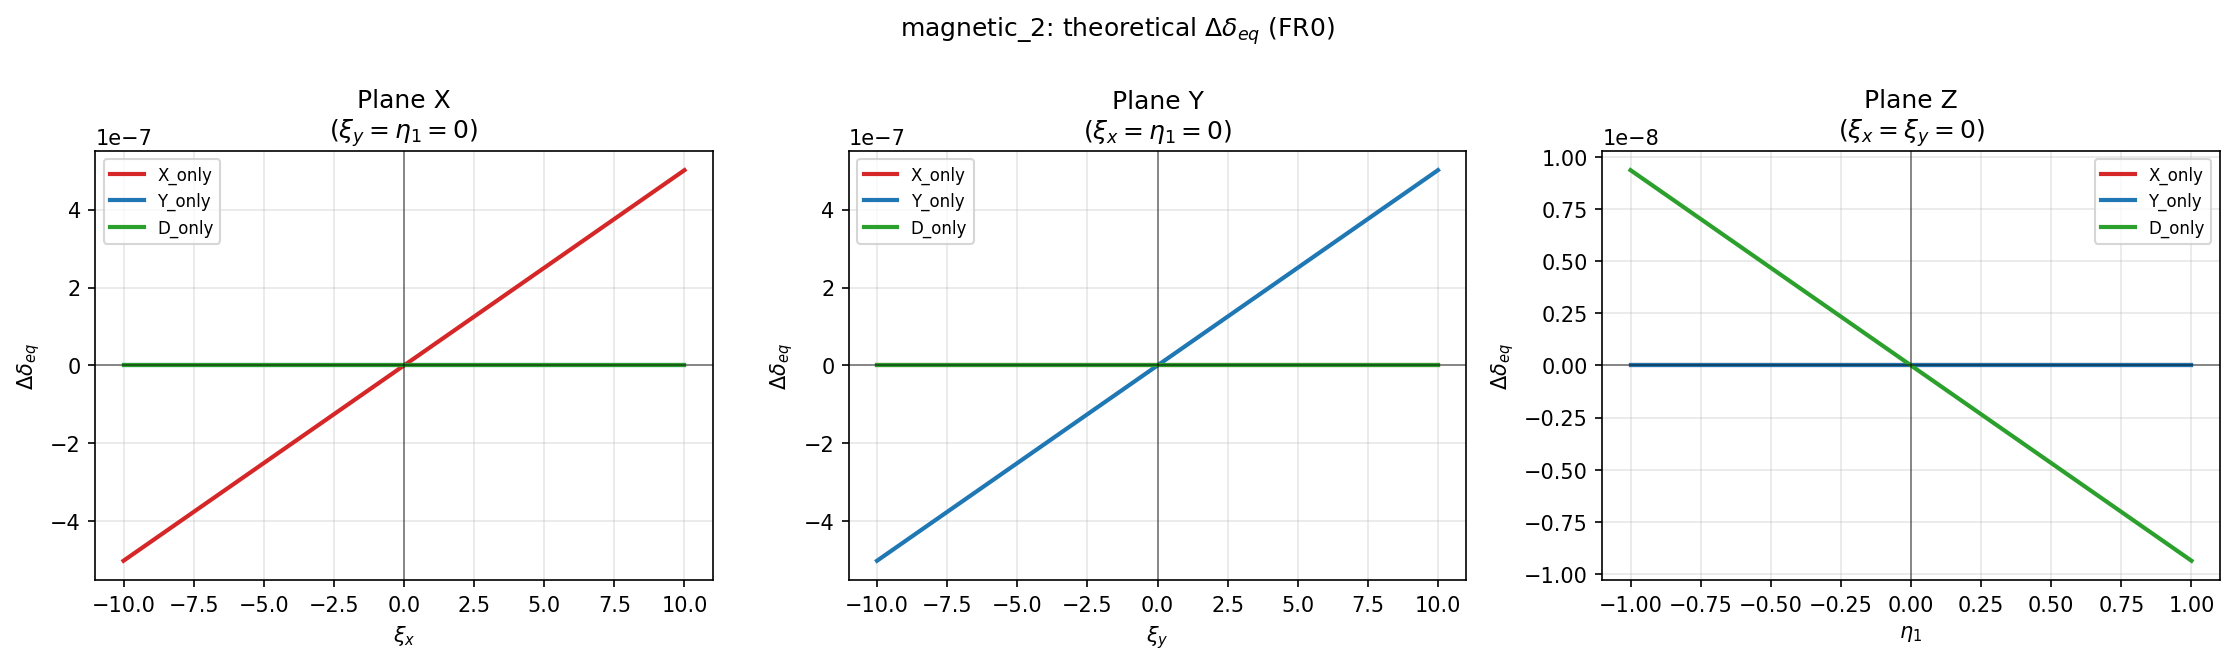

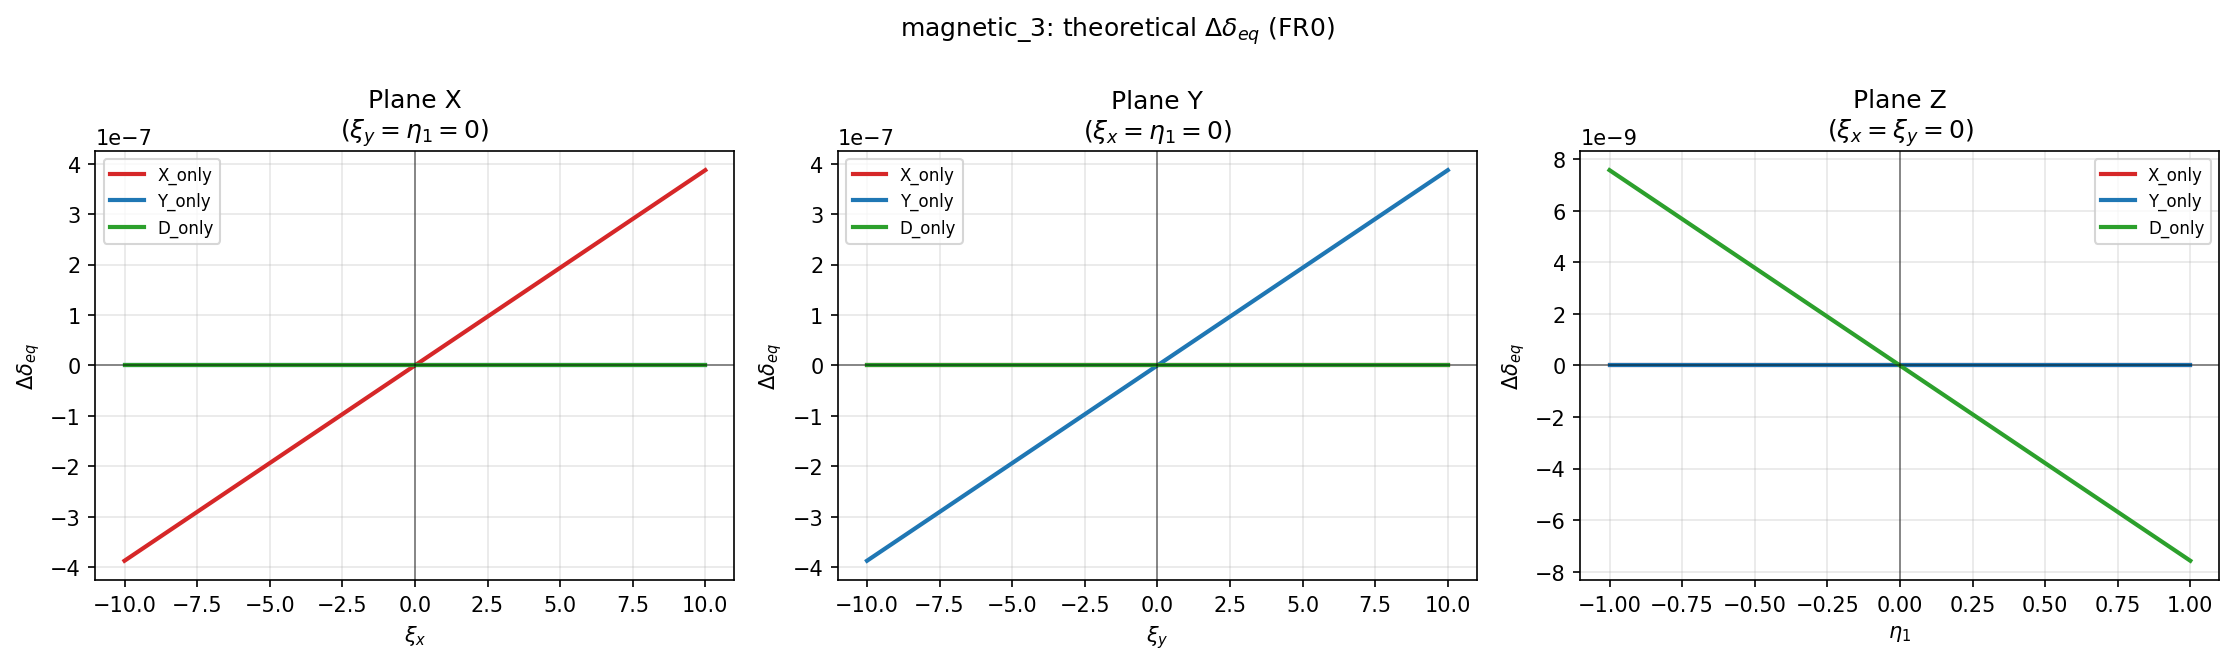

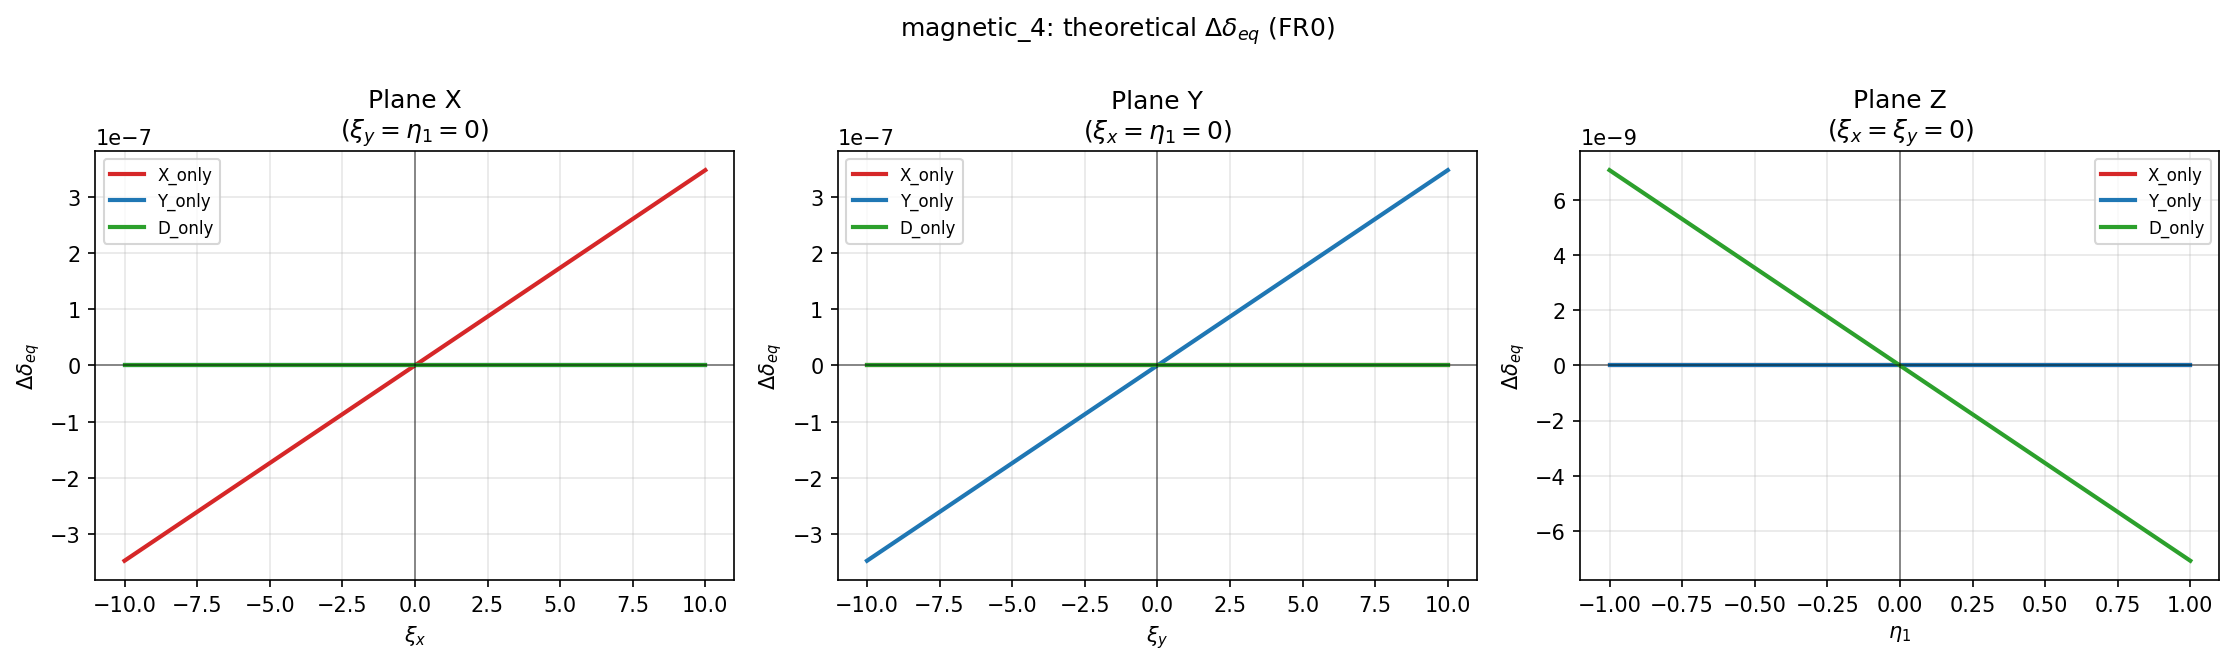

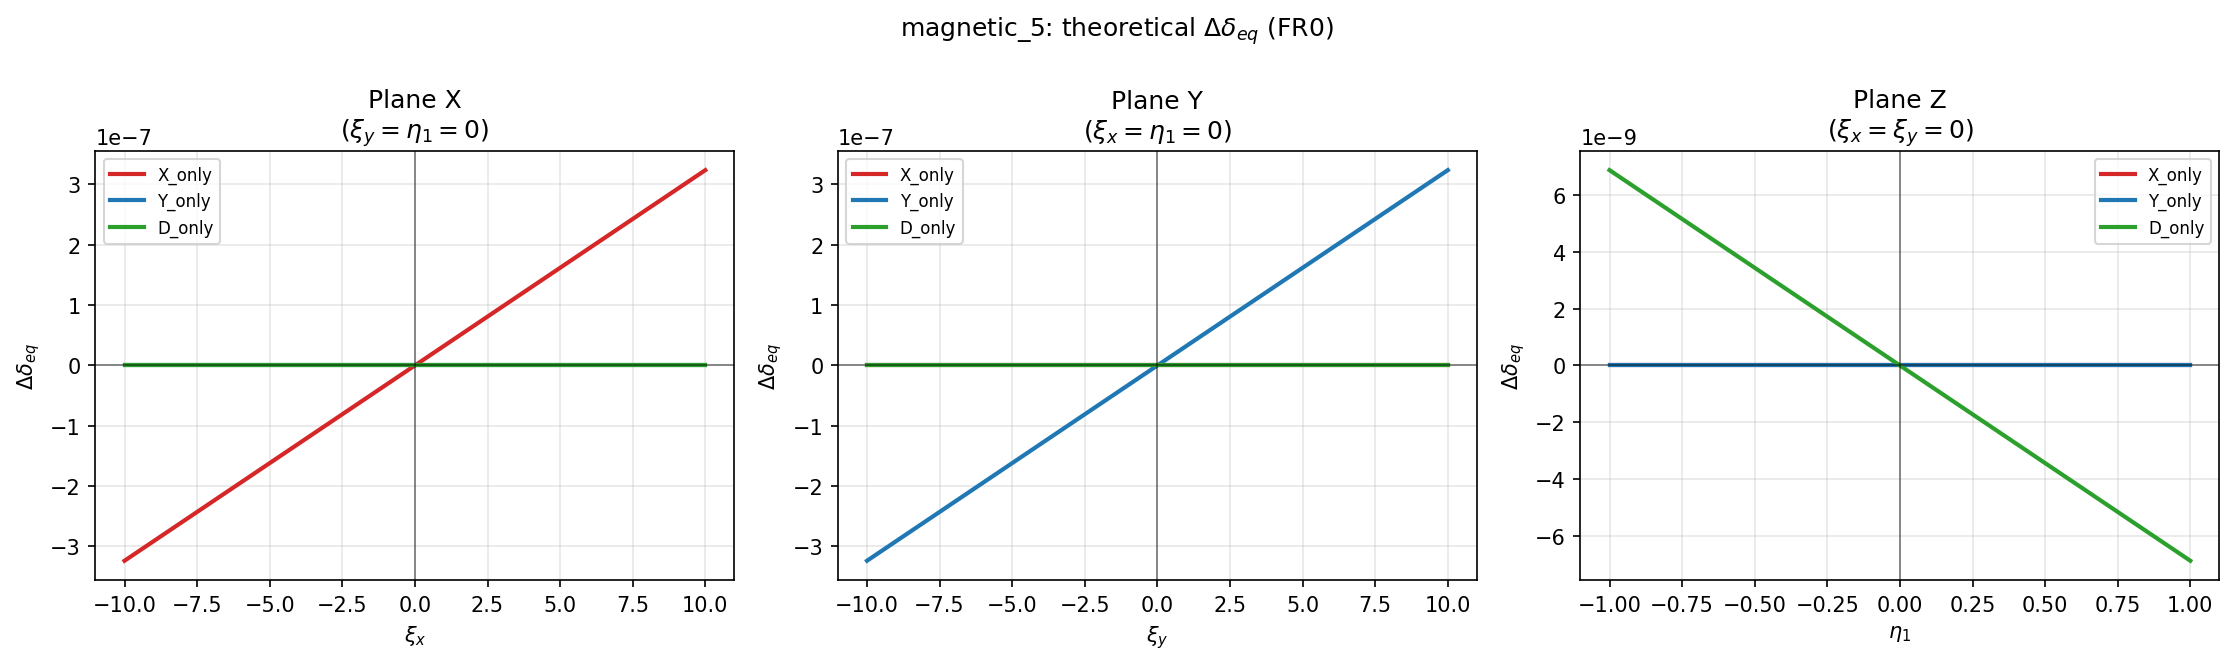

,stem,scenario,Delta_delta_eq@I*
0,magnetic_2,X_only,-1.113134e-23
1,magnetic_2,Y_only,-1.113134e-23
2,magnetic_2,D_only,-2.079660e-24
3,magnetic_3,X_only,-1.720486e-23
4,magnetic_3,Y_only,-1.720486e-23
5,magnetic_3,D_only,-0.000000e+00
6,magnetic_4,X_only,6.170243e-23
7,magnetic_4,Y_only,-1.234049e-22
8,magnetic_4,D_only,3.147102e-24
9,magnetic_5,X_only,-2.874598e-23


In [8]:
import numpy as np

rows = []
for stem in STEMS:
    df = get_data(stem, "FR0")
    m = get_dual_model(df)
    I = solve_currents(m["R_int"], m["int_nat"], np.zeros(3))
    pred = m["R_int"] @ I + m["int_nat"]
    alpha0 = float(df["alpha_0"].mean())
    L = lattice_length(stem)
    for name, sc in cfg["emittance_scenarios"].items():
        dde = delta_eq_theory(
            pred[0], pred[1], pred[2], alpha0,
            L=L, gamma=g,
            eps_x=sc["eps_x"], eps_y=sc["eps_y"], delta_m=sc["delta_m"],
        )
        rows.append({"stem": stem, "scenario": name, "Delta_delta_eq@I*": dde})
    p = PLOTS / f"{stem}_delta_eq_panels.png"
    if p.is_file():
        display(Image(filename=str(p)))
pd.DataFrame(rows)


## 4. Фаза на каждом экземпляре секступоля

SF1, SF2 и SD — семейства; на рисунках и в суммах ниже учитывается каждый отдельный экземпляр секступоля в решётке. Его вклад определяется не только знаком и коэффициентом $K_2$, но и местной оптикой.

Истинная бетатронная фаза задаётся Twiss-функциями:

$$
\psi_x(s)=\int_0^s\frac{ds'}{\beta_x(s')},\qquad
\psi_y(s)=\int_0^s\frac{ds'}{\beta_y(s')}.
$$

Старый угол $2\pi Qs/C$ подразумевал равномерное накопление фазы вдоль кольца. Он годится, чтобы увидеть порядок расположения элементов, но не является фазой для resonance driving term. Новый расчёт читает `BETAX`/`BETAY`, интегрирует $ds/\beta$ по элементам и сравнивает обе величины.

Линейные Twiss-функции на закрытой орбите не зависят от силы секступоля первого порядка, поэтому существующие `BETAX`/`BETAY` применимы для оценки фазы при $I^*$. Однако сама физическая сила конкретного RDT требует ещё $K_2L$, степеней $\beta_{x,y}$ и комбинации фаз; результирующий вектор ниже — диагностическая фазово-взвешенная сумма, не полный расчёт RDT.

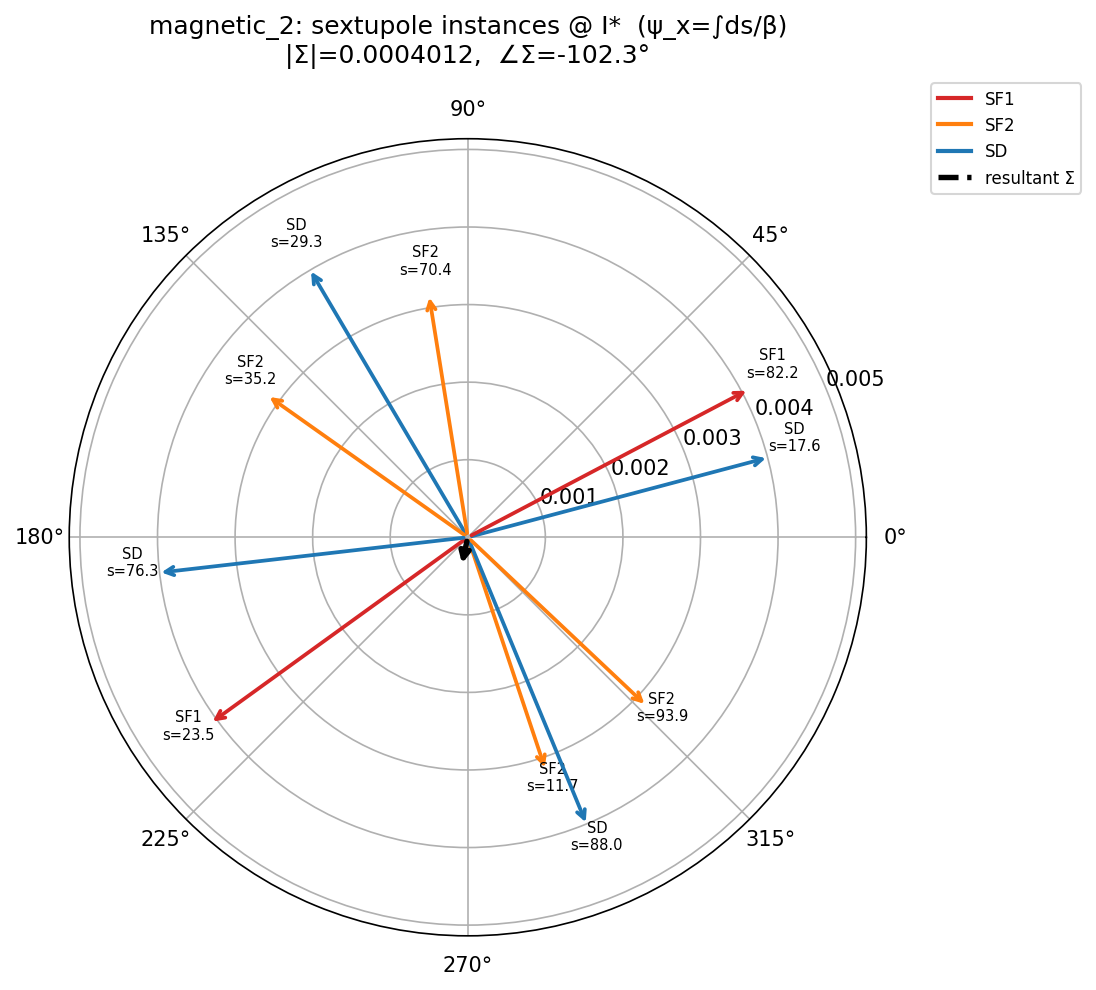

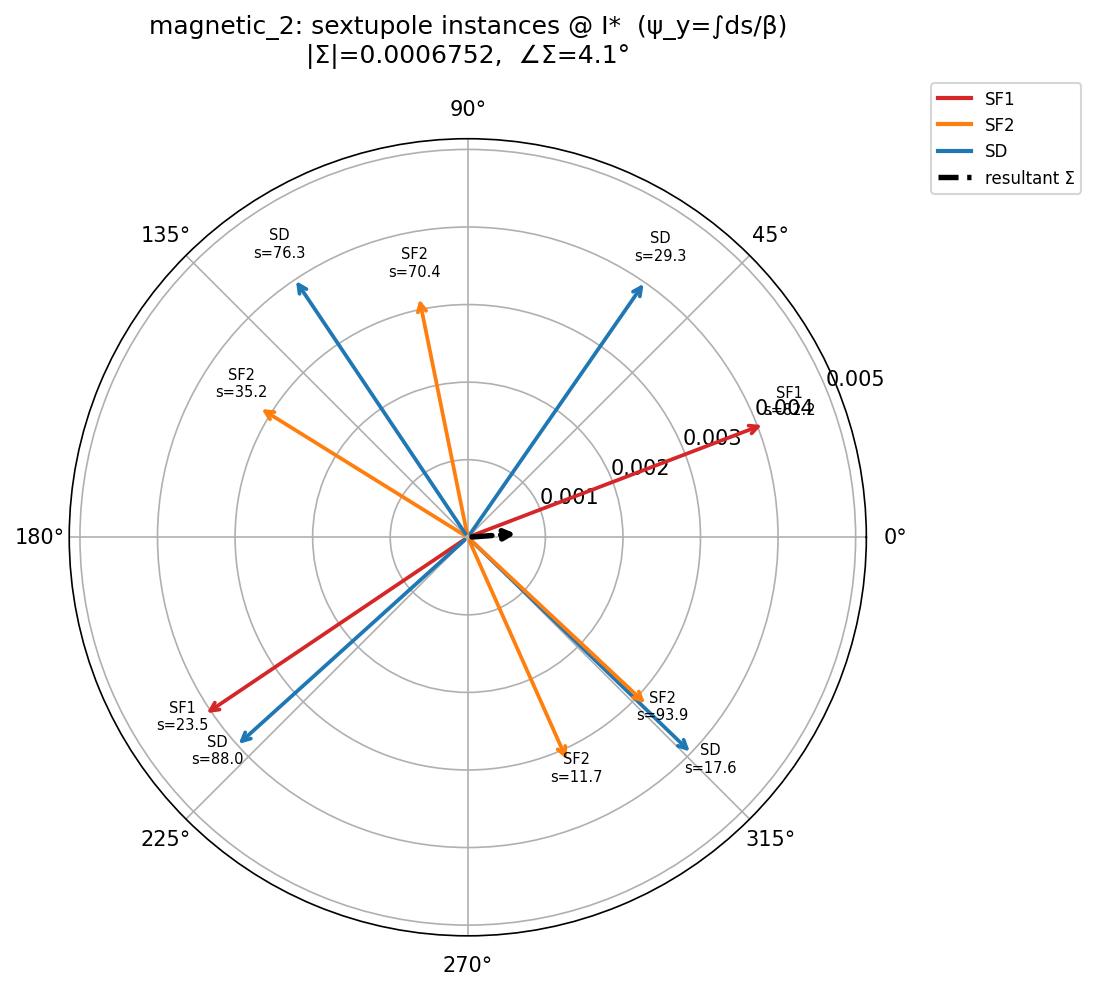

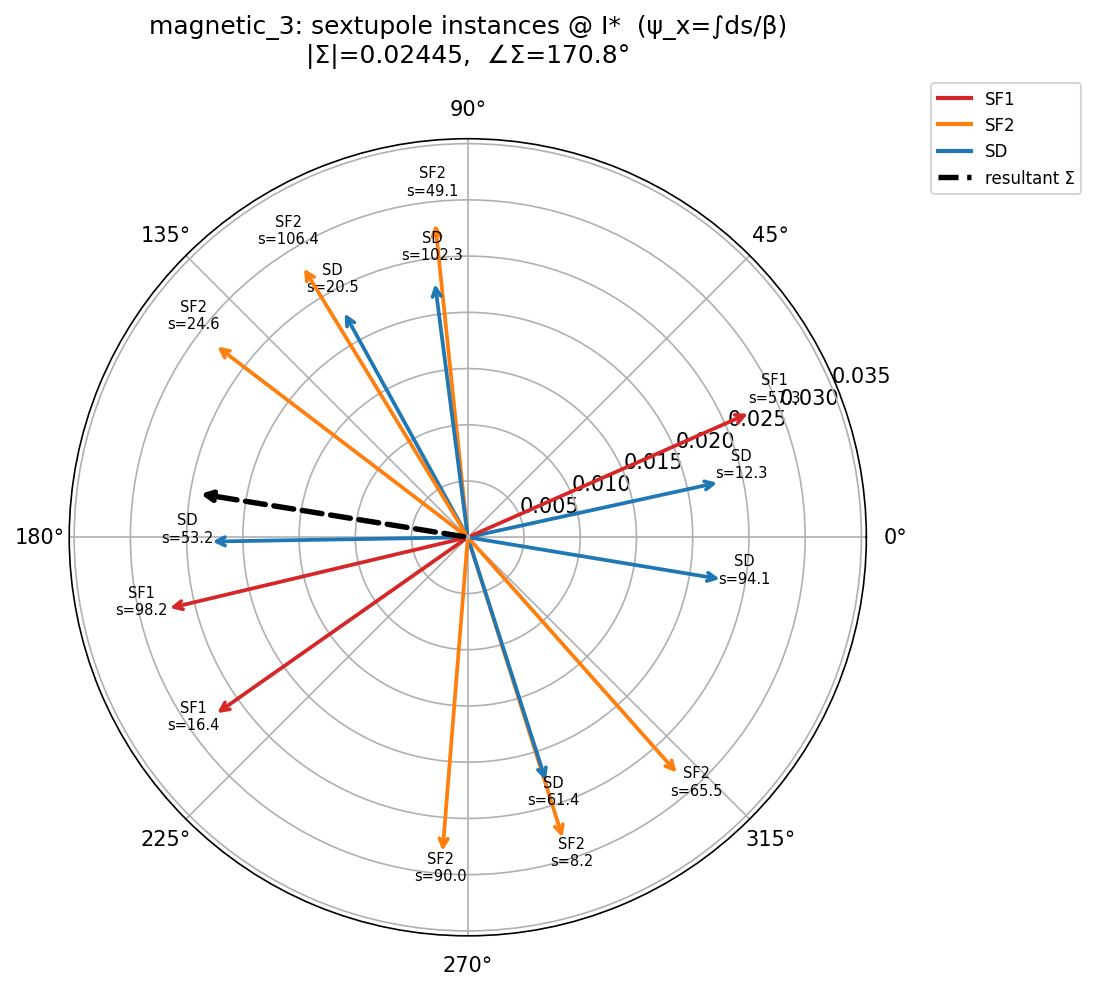

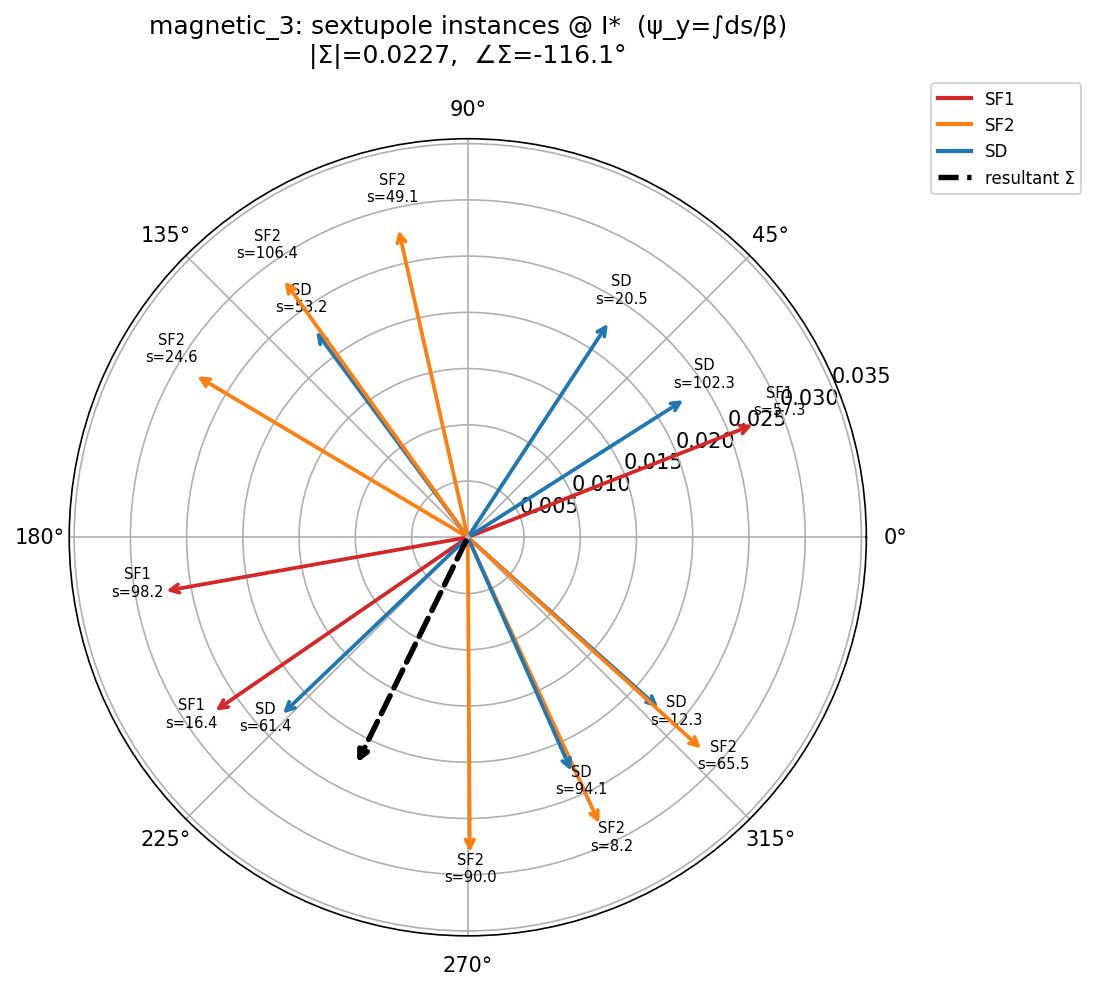

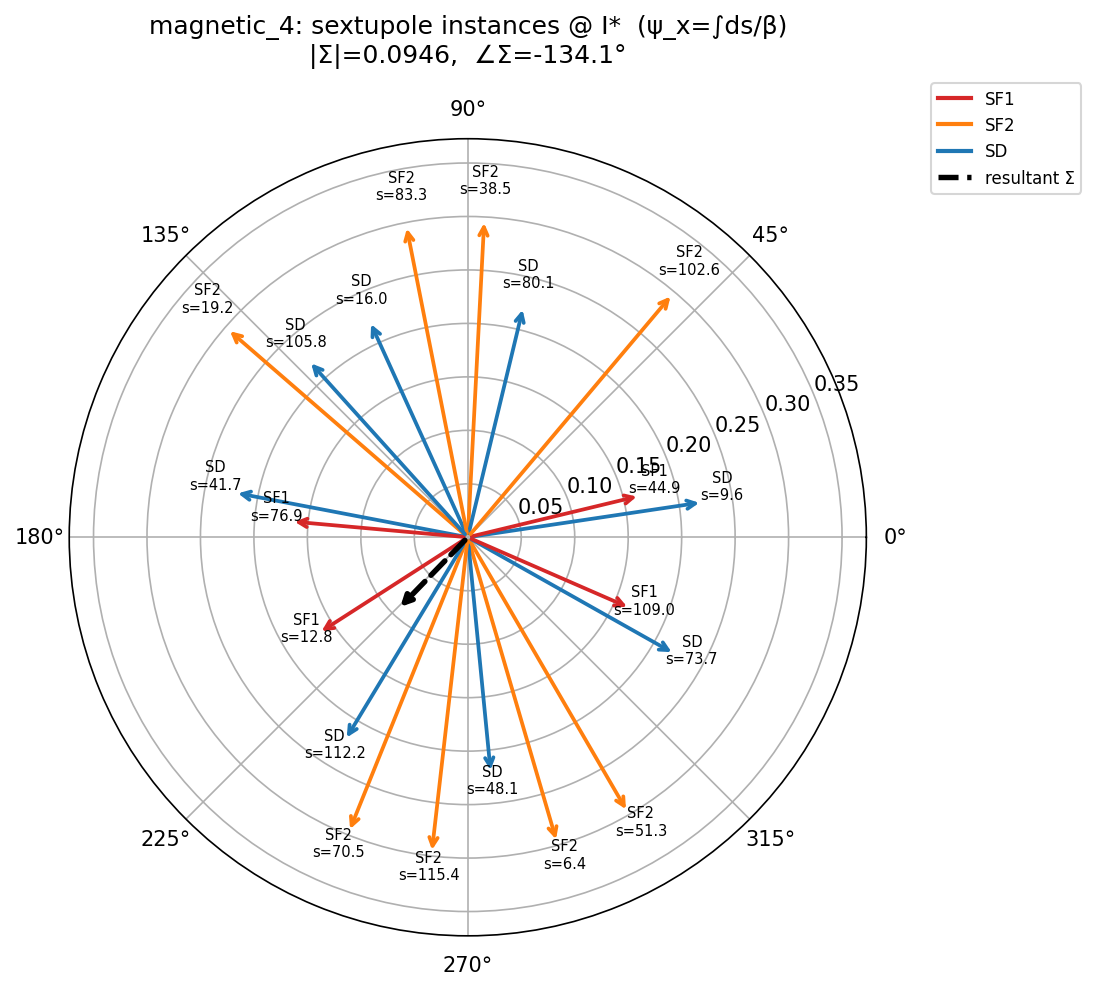

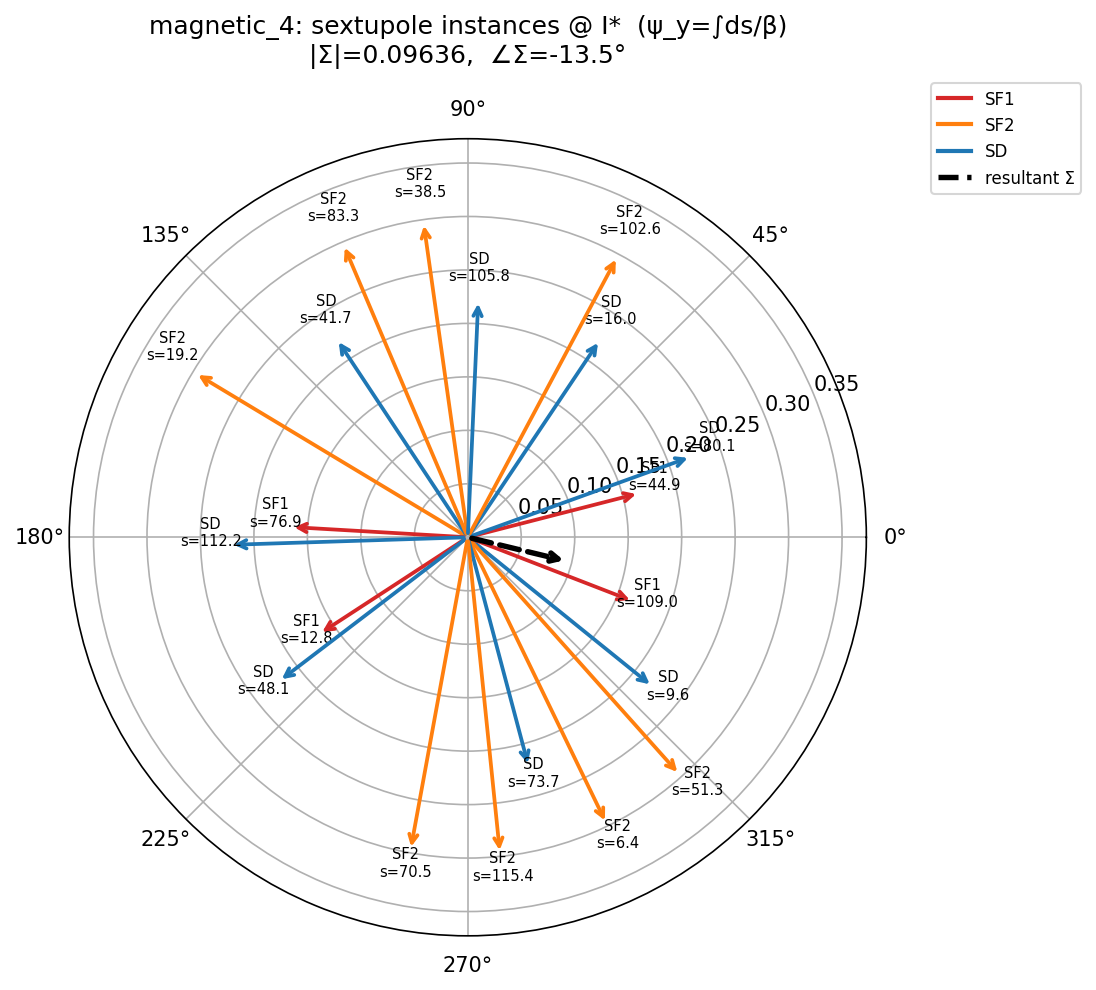

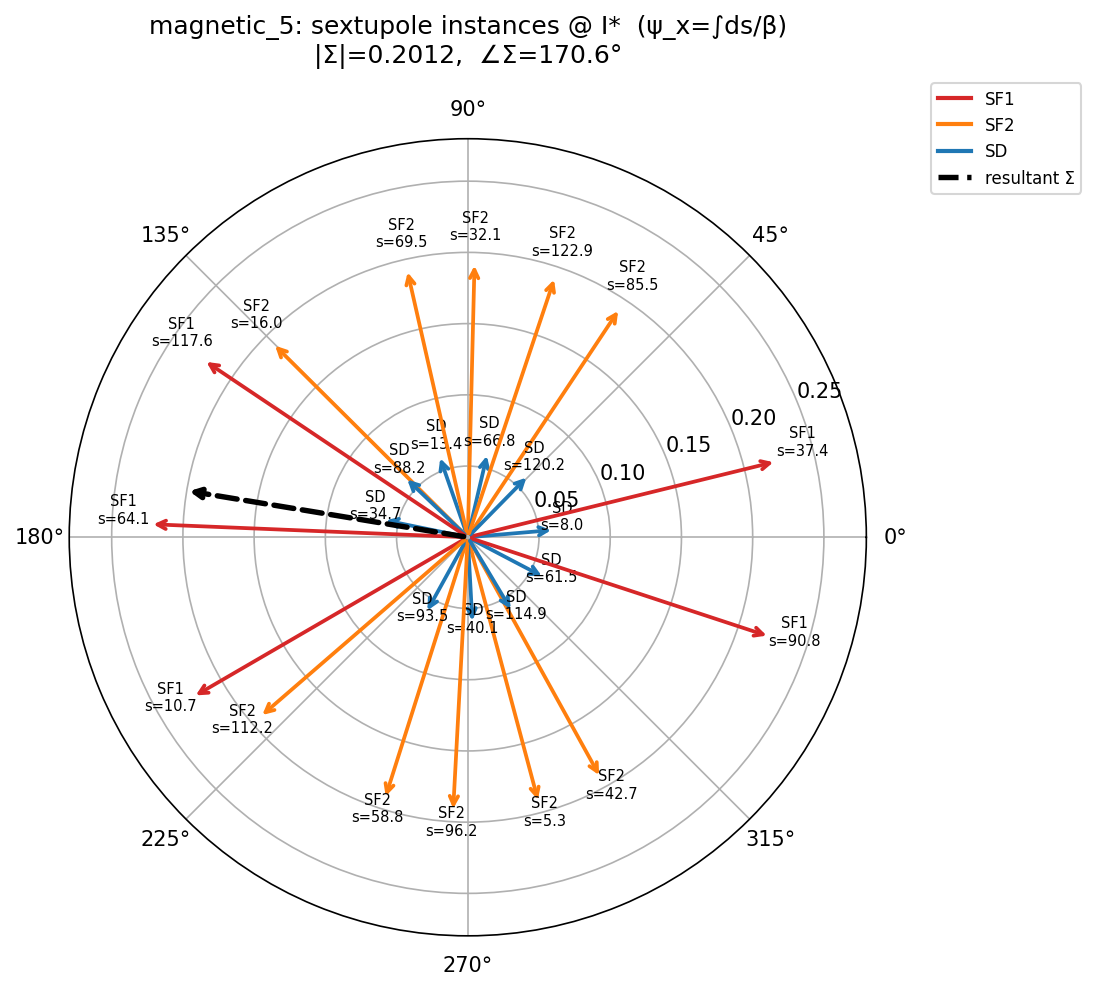

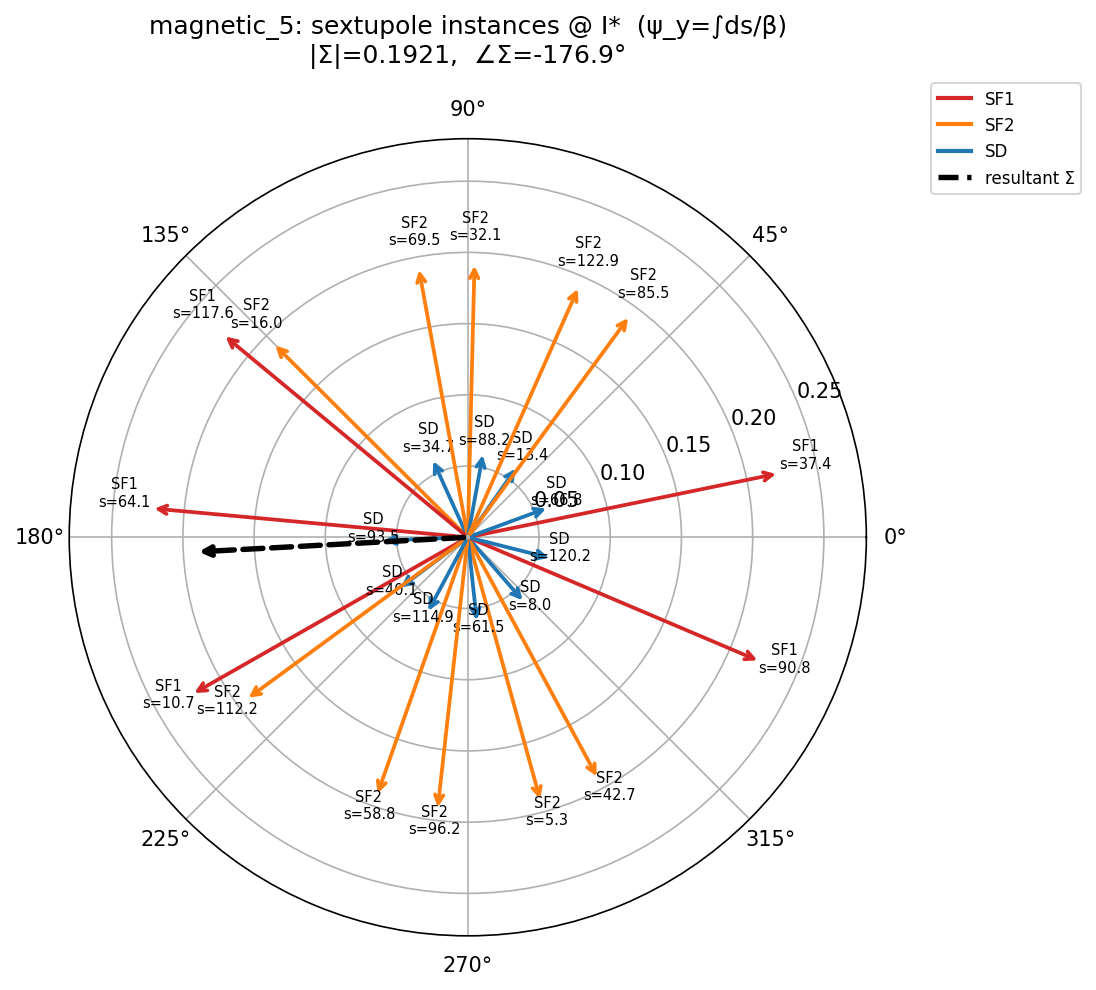

,stem,n_instances,rms_dpsi_x,rms_dpsi_y,|Σ|_x,|Σ|_y
0,magnetic_2,10,2.02036,2.25012,0.00040,0.00068
1,magnetic_3,15,1.80298,1.92630,0.02445,0.02270
2,magnetic_4,20,1.76462,1.85122,0.09460,0.09636
3,magnetic_5,25,1.84689,1.82261,0.20120,0.19211


In [9]:
phase_rows = []
for stem in STEMS:
    path = DAT_OUT / stem / "sext_phase_twiss.json"
    if not path.is_file():
        continue
    d = json.loads(path.read_text(encoding="utf-8"))
    phase_rows.append({
        "stem": stem,
        "n_instances": d["n_sextupole_instances"],
        "rms_dpsi_x": d["rms_dpsi_x_rad"],
        "rms_dpsi_y": d["rms_dpsi_y_rad"],
        "|Σ|_x": d["resultant"]["x"]["magnitude"],
        "|Σ|_y": d["resultant"]["y"]["magnitude"],
    })
    for plane in ("x", "y"):
        p = PLOTS / f"{stem}_sext_phase_twiss_{plane}.png"
        if p.is_file():
            display(Image(filename=str(p)))
pd.DataFrame(phase_rows).round(5)


## 5. Спиновые резонансы: что именно сканируется

Резонансный scan сначала отвечает на геометрический вопрос: близка ли центральная spin tune к разрешённой комбинации орбитальных частот? Используются линии

$$
\nu_s=k,\qquad
\nu_s=k\pm Q_x,\quad k\pm Q_y,
$$

для имперфекционных и внутренних резонансов, а при продольном движении также

$$
\nu_s=k\pm mQ_s,\qquad
\nu_s=k\pm Q_{x,y}\pm mQ_s.
$$

Расстояние в таблице — расстояние до ближайшей периодической линии в tune-пространстве. Малое расстояние необходимо для сильного резонанса, но само по себе недостаточно: нужна ещё сила возбуждения — поля ошибок, closed orbit, амплитуда бетатронного движения, RDT и спектральный отклик спина.

Для дейтрона $|G\gamma|\simeq0.164$ существенно меньше, чем для протона при той же $\gamma$. Из этого нельзя делать вывод «резонансов нет»: меняется набор ближайших гармоник и их силы. Более того, сохранение поляризации $|\langle\mathbf S\rangle|$ слабее, чем сохранение когерентности: пучок может оставаться поляризованным при разлёте индивидуальных фаз.

Пока $Q_s$ взят как явная оценка из конфига; для количественной оценки synchrotron sidebands его нужно извлечь из RF one-turn map или dense продольного трекинга.

,stem,imperfection_dist,imperfection_form,intrinsic_dist,intrinsic_form,synchrotron_dist,synchrotron_form,combined_dist,combined_form,C_final_proxy,track_aliased
0,magnetic_2,0.163565,ν_s=5,0.282719,ν_s=4+Q_x,0.143565,ν_s=1+2Q_s,0.262719,ν_s=1+Q_x-2Q_s,1.0,False
1,magnetic_3,0.163565,ν_s=0,0.126914,ν_s=3-Q_x,0.143565,ν_s=0+2Q_s,0.106914,ν_s=3-Q_x-2Q_s,NaN,None
2,magnetic_4,0.163565,ν_s=5,0.075273,ν_s=6-Q_y,0.143565,ν_s=1+2Q_s,0.055273,ν_s=0-Q_y+2Q_s,NaN,None
3,magnetic_5,0.163565,ν_s=3,0.063876,ν_s=1+Q_y,0.143565,ν_s=3+2Q_s,0.043876,ν_s=1+Q_y-2Q_s,NaN,None


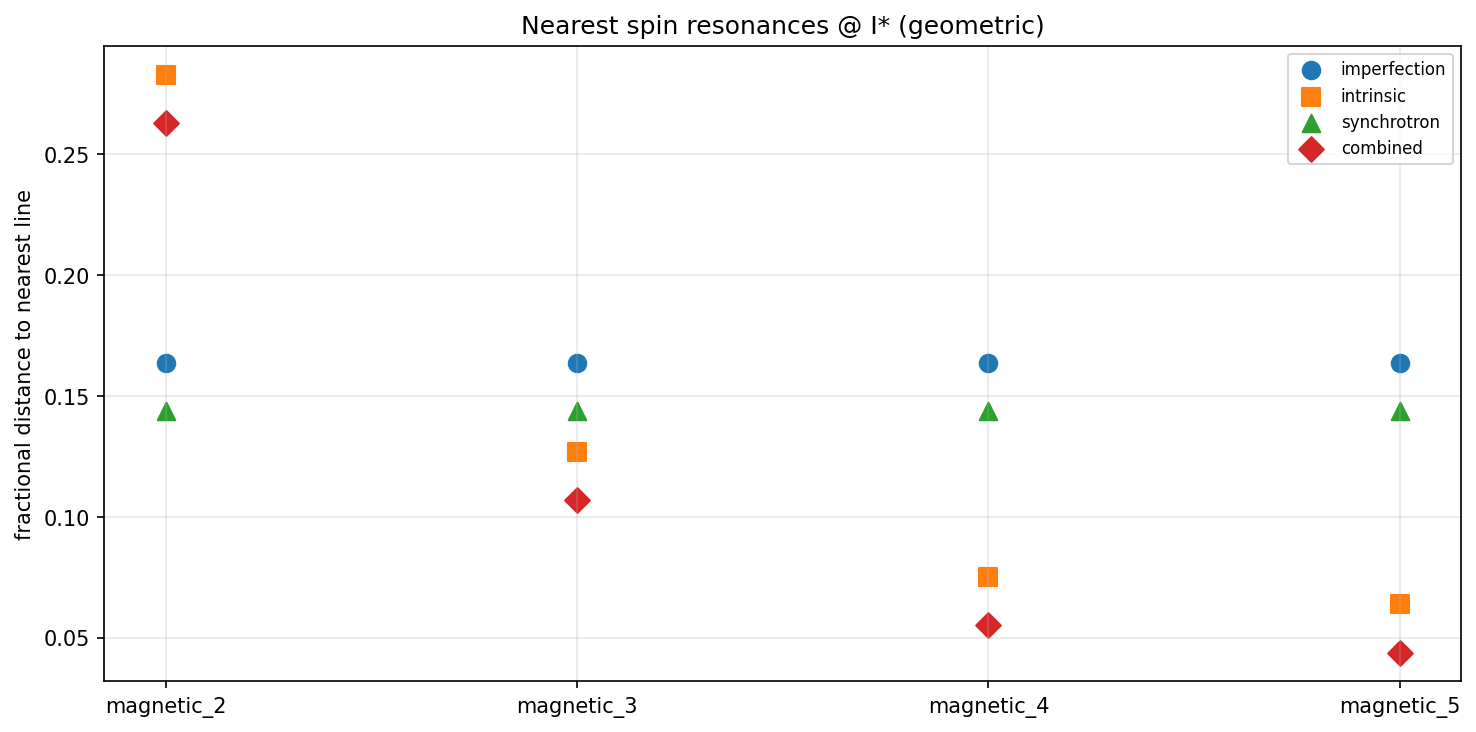

deuteron gammaG: -0.16356483111800002
proton gammaG at same gamma: 2.0508632407236003
Deuteron |Gγ|≪1 keeps low-order imperfection lines farther in absolute spin tune than for protons at the same γ; this does not prove resonances are irrelevant for coherence — check distances and observed excitation.


In [10]:
res_rows = []
for stem in STEMS:
    path = DAT_OUT / stem / "resonance_scan.json"
    if not path.is_file():
        continue
    d = json.loads(path.read_text(encoding="utf-8"))
    ist = d["points"].get("Istar", {})
    nb = ist.get("nearest_by_kind", {})
    row = {"stem": stem}
    for kind in ("imperfection", "intrinsic", "synchrotron", "combined"):
        r = nb.get(kind) or {}
        row[f"{kind}_dist"] = r.get("distance")
        row[f"{kind}_form"] = r.get("form")
    tp = ist.get("tracking_proxy") or {}
    row["C_final_proxy"] = tp.get("C_final")
    row["track_aliased"] = tp.get("sampling_aliased")
    res_rows.append(row)
display(pd.DataFrame(res_rows))
p = PLOTS / "resonance_scan_summary.png"
if p.is_file():
    display(Image(filename=str(p)))
pc = json.loads((DAT_OUT / STEMS[0] / "resonance_scan.json").read_text(encoding="utf-8"))["proton_comparison"]
print("deuteron gammaG:", pc["deuteron_gammaG"])
print("proton gammaG at same gamma:", pc["proton_gammaG_same_gamma"])
print(pc["note"])


## 6. Multi-turn: ансамбль, усреднение и спиновая фаза (`magnetic_2`)

Шаблон `INJECT` создаёт reference-луч и три диагностические группы: X с $X_0\in[-1,1]$ mm, Y с тем же диапазоном по $Y_0$, D с начальным импульсным отклонением. Это не matched-ансамбль пучка; он намеренно разделяет поперечный и продольный механизмы.

Для каждого луча после отбрасывания первых 20% срезов вычисляется

$$
\overline D_i=\frac{1}{N_t}\sum_{n\ge n_1}D_i(n),\qquad
\mathrm{mean\_D\_offset}_i=\overline D_i-\overline D_{\rm ref}.
$$

Это именно измеряемый multi-turn proxy. Он позволяет проверить предсказание «обнуление $\xi$ подавляет поперечный вклад», но не следует называть его $\Delta\delta_{eq}$.

Для спина используется горизонтальный начальный вектор `psi_deg=0`, $\mathbf S_0=(0,0,1)$, и фаза в плоскости XZ:

$$
\phi_i(n)=\operatorname{unwrap}\!\left[\operatorname{atan2}(S_{x,i}(n),S_{z,i}(n))\right].
$$

Относительная фаза $\Delta\phi_i=\phi_i-\phi_{\rm ref}$ даёт

$$
C(n)=\left|\frac1N\sum_i e^{i\Delta\phi_i(n)}\right|.
$$

`dense` сохраняет спин раз в два оборота. При $|\nu_s|\simeq0.1636$ предел Найквиста — около трёх оборотов, поэтому здесь unwrap и fit осмысленны. `smoke` (10 оборотов) и прежний `full` (100) для спина алиасированы; они пригодны для орбитального proxy, но не для $\Delta\nu_s$. Вертикальный спин (`psi=90`) также не подходит к этой фазовой плоскости: его проекция на XZ почти нулевая.

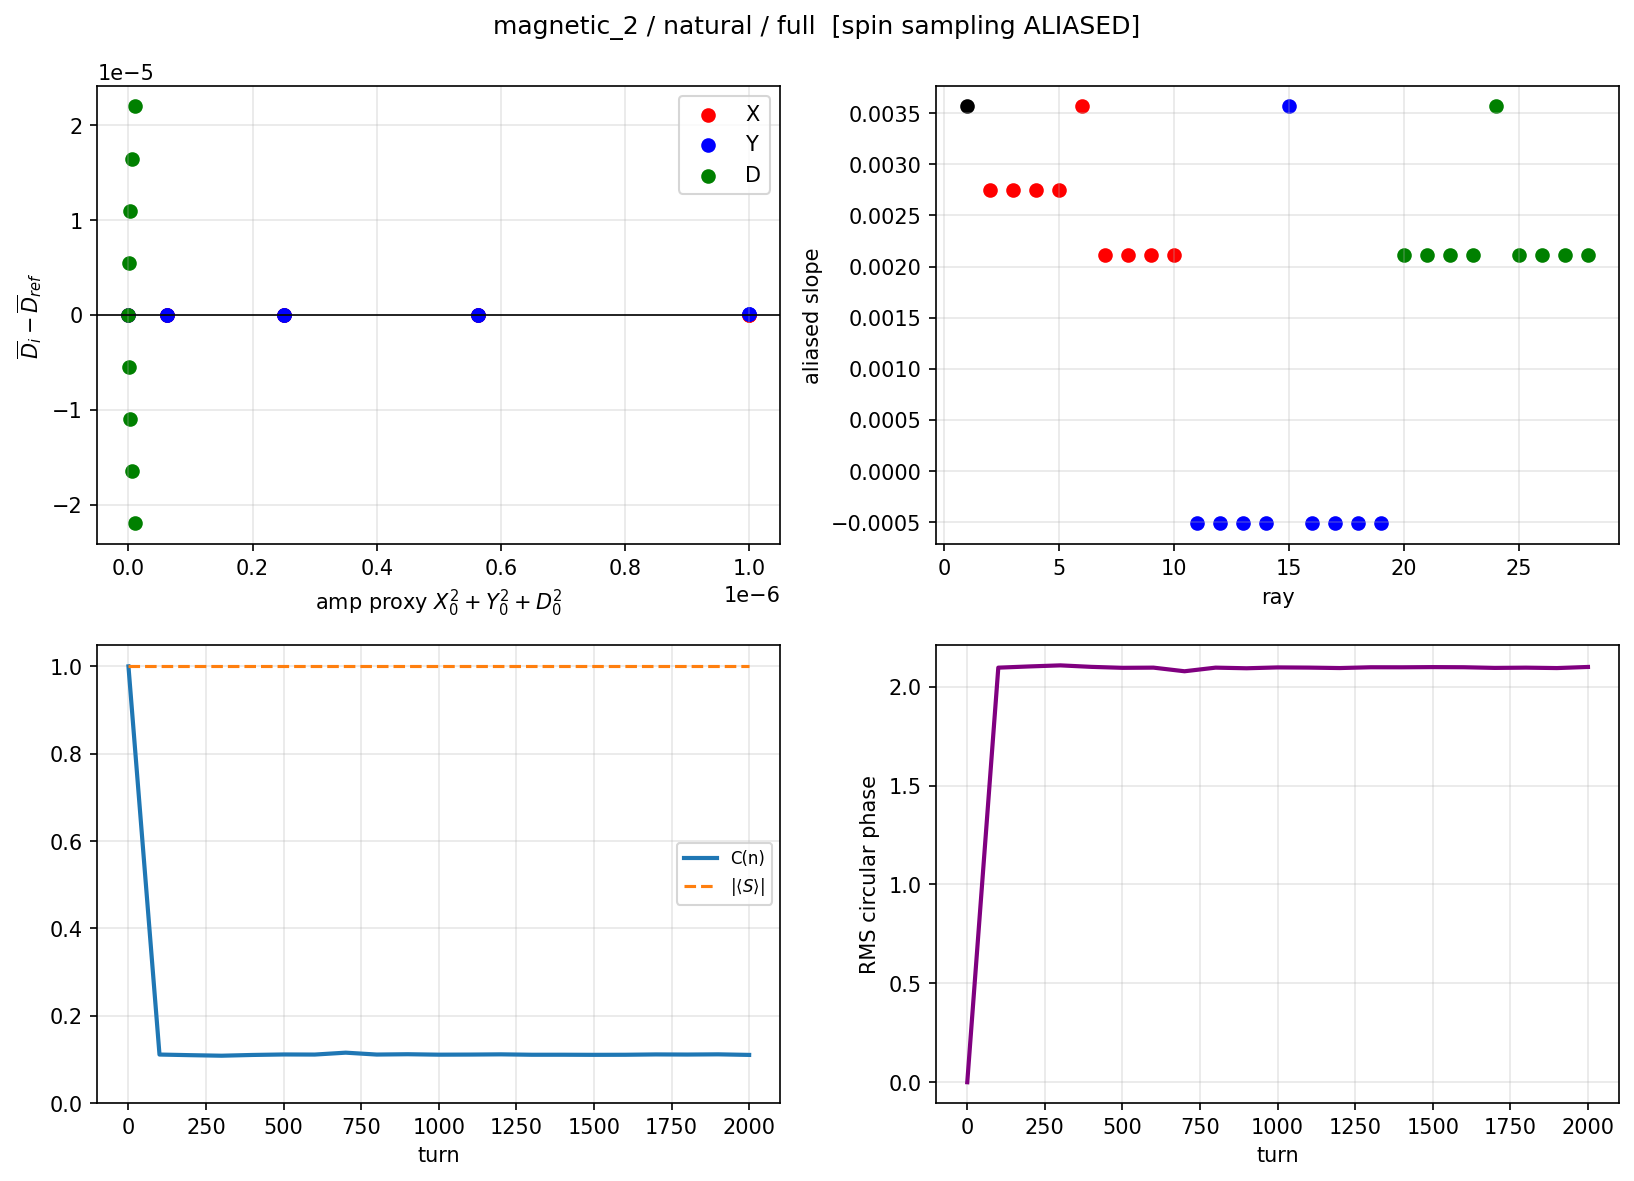

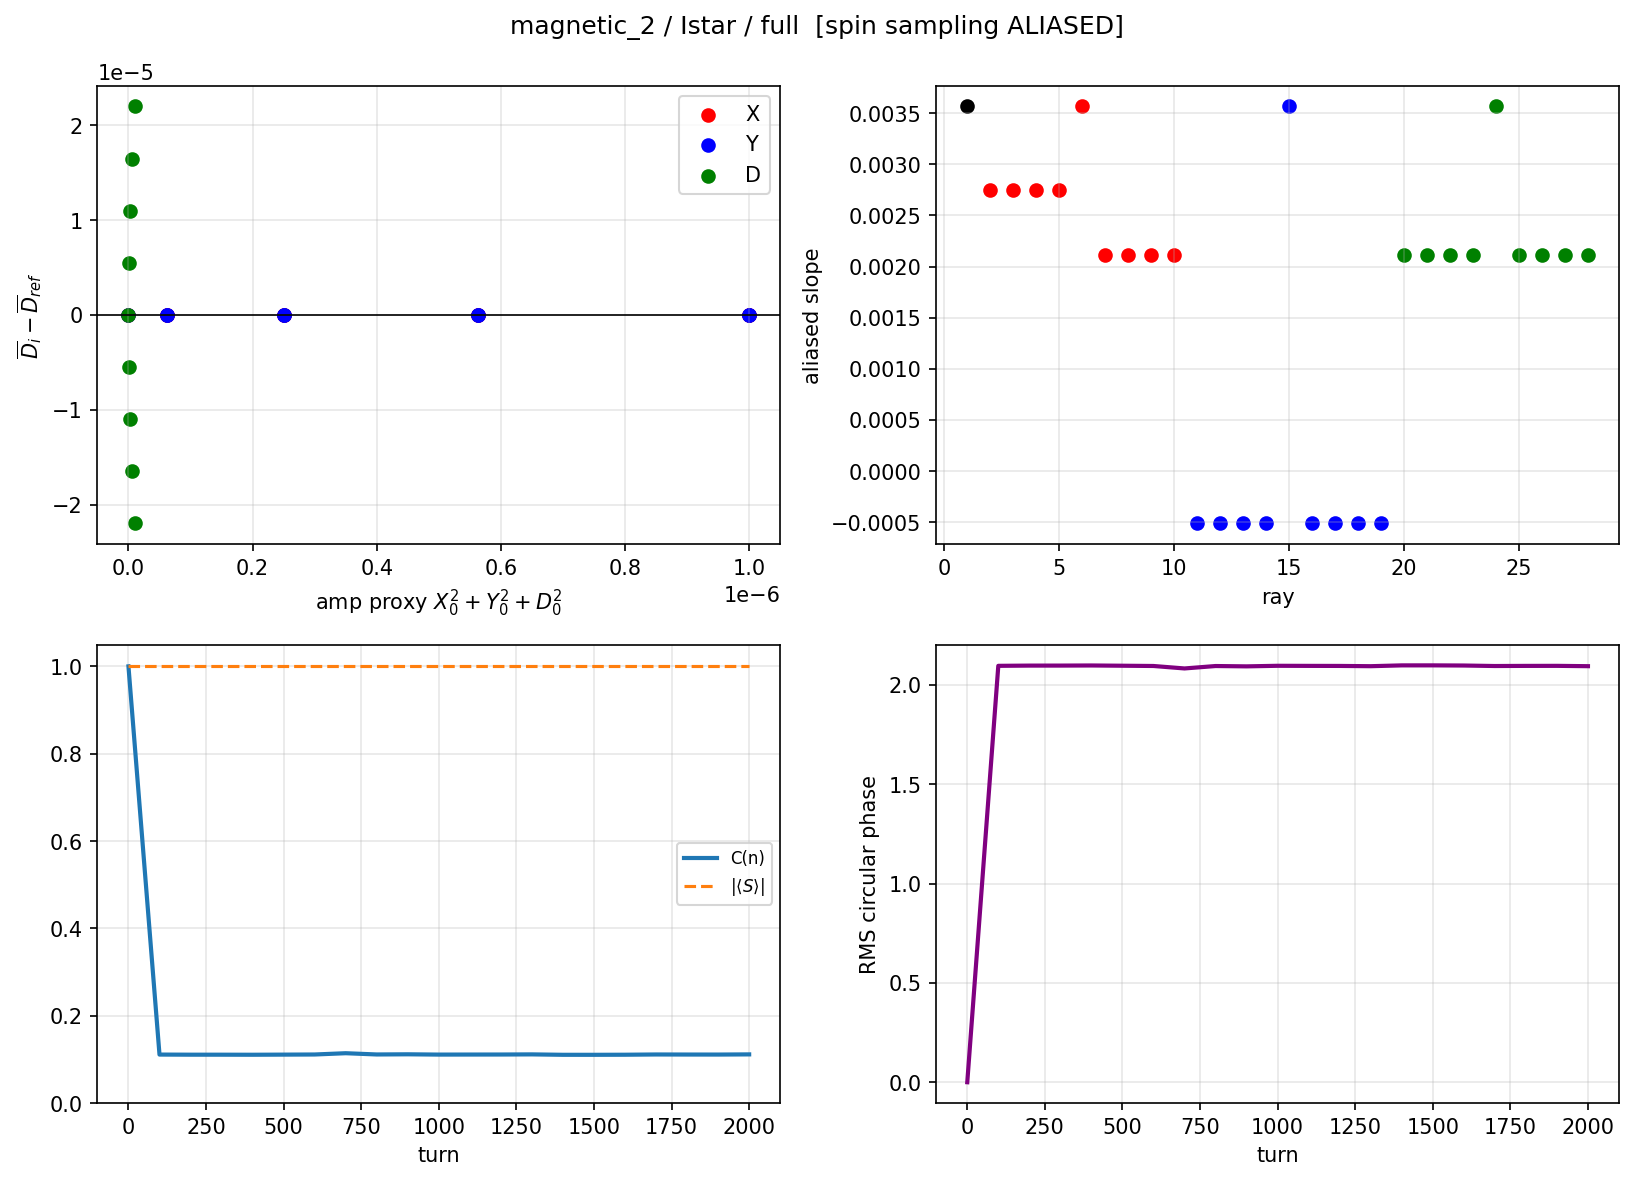

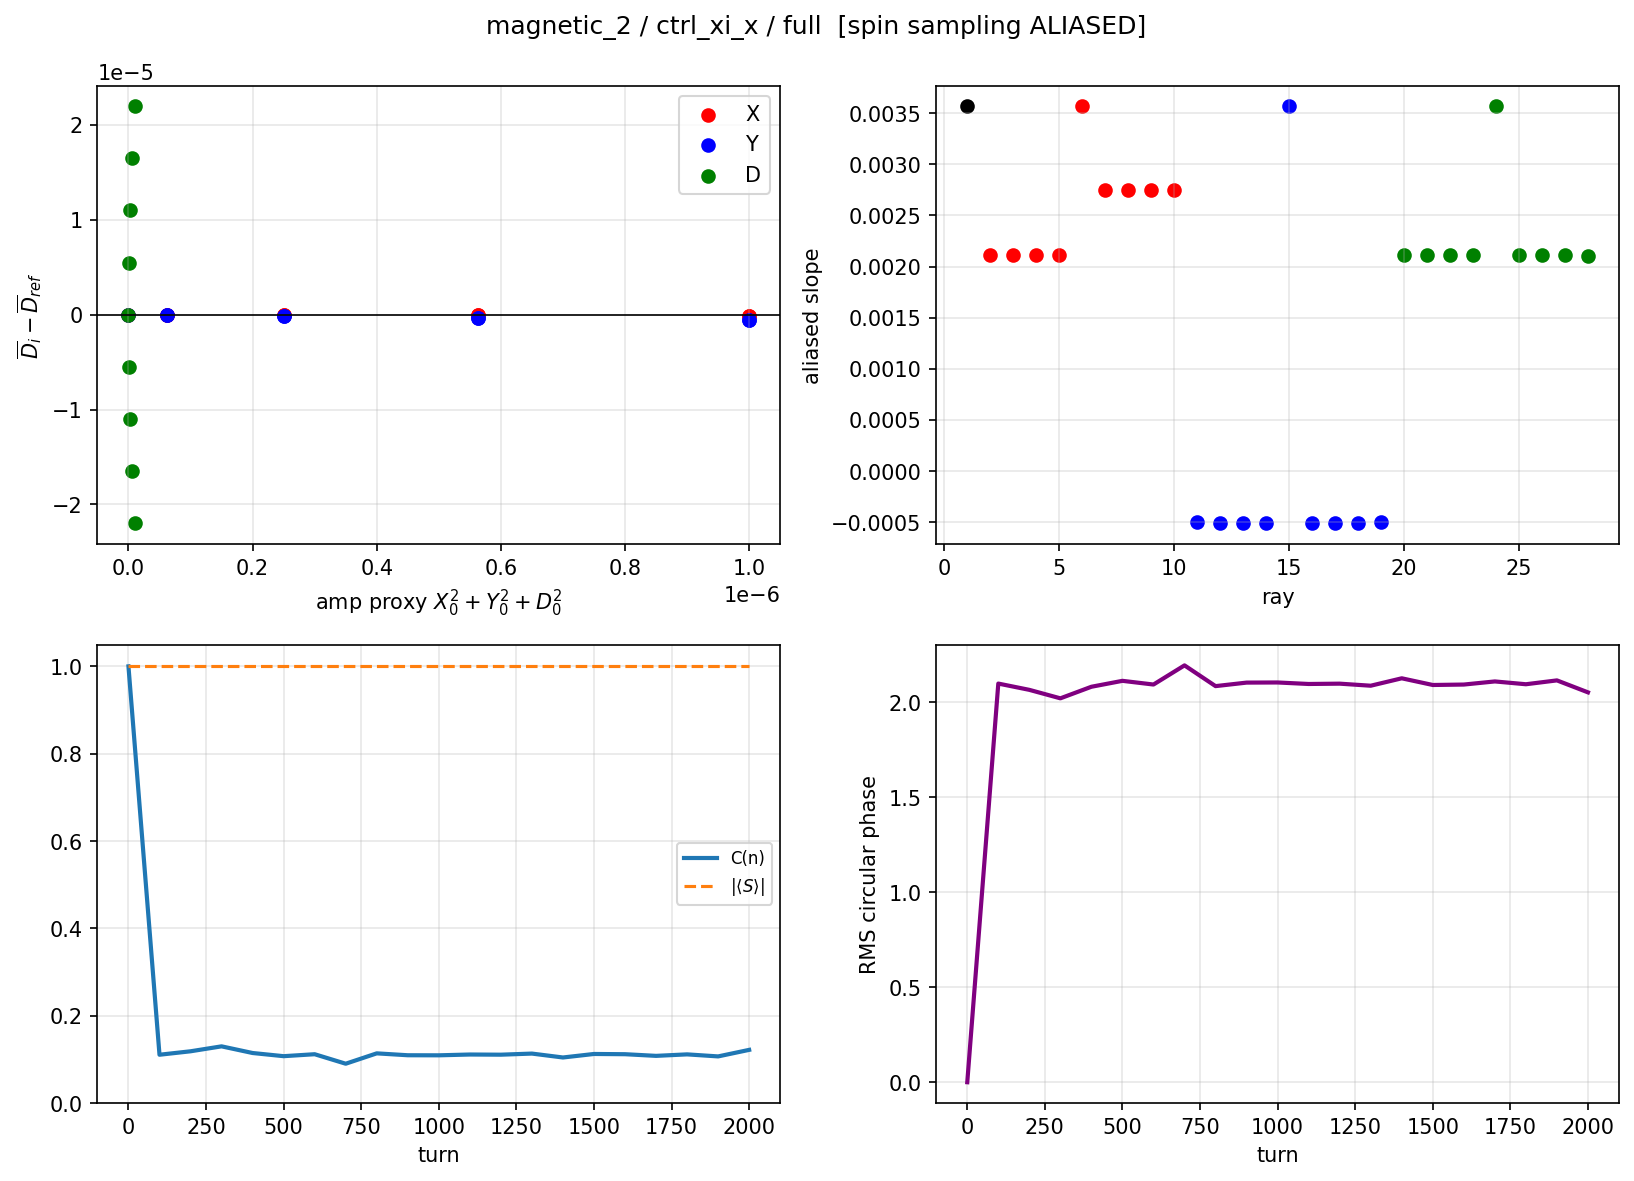

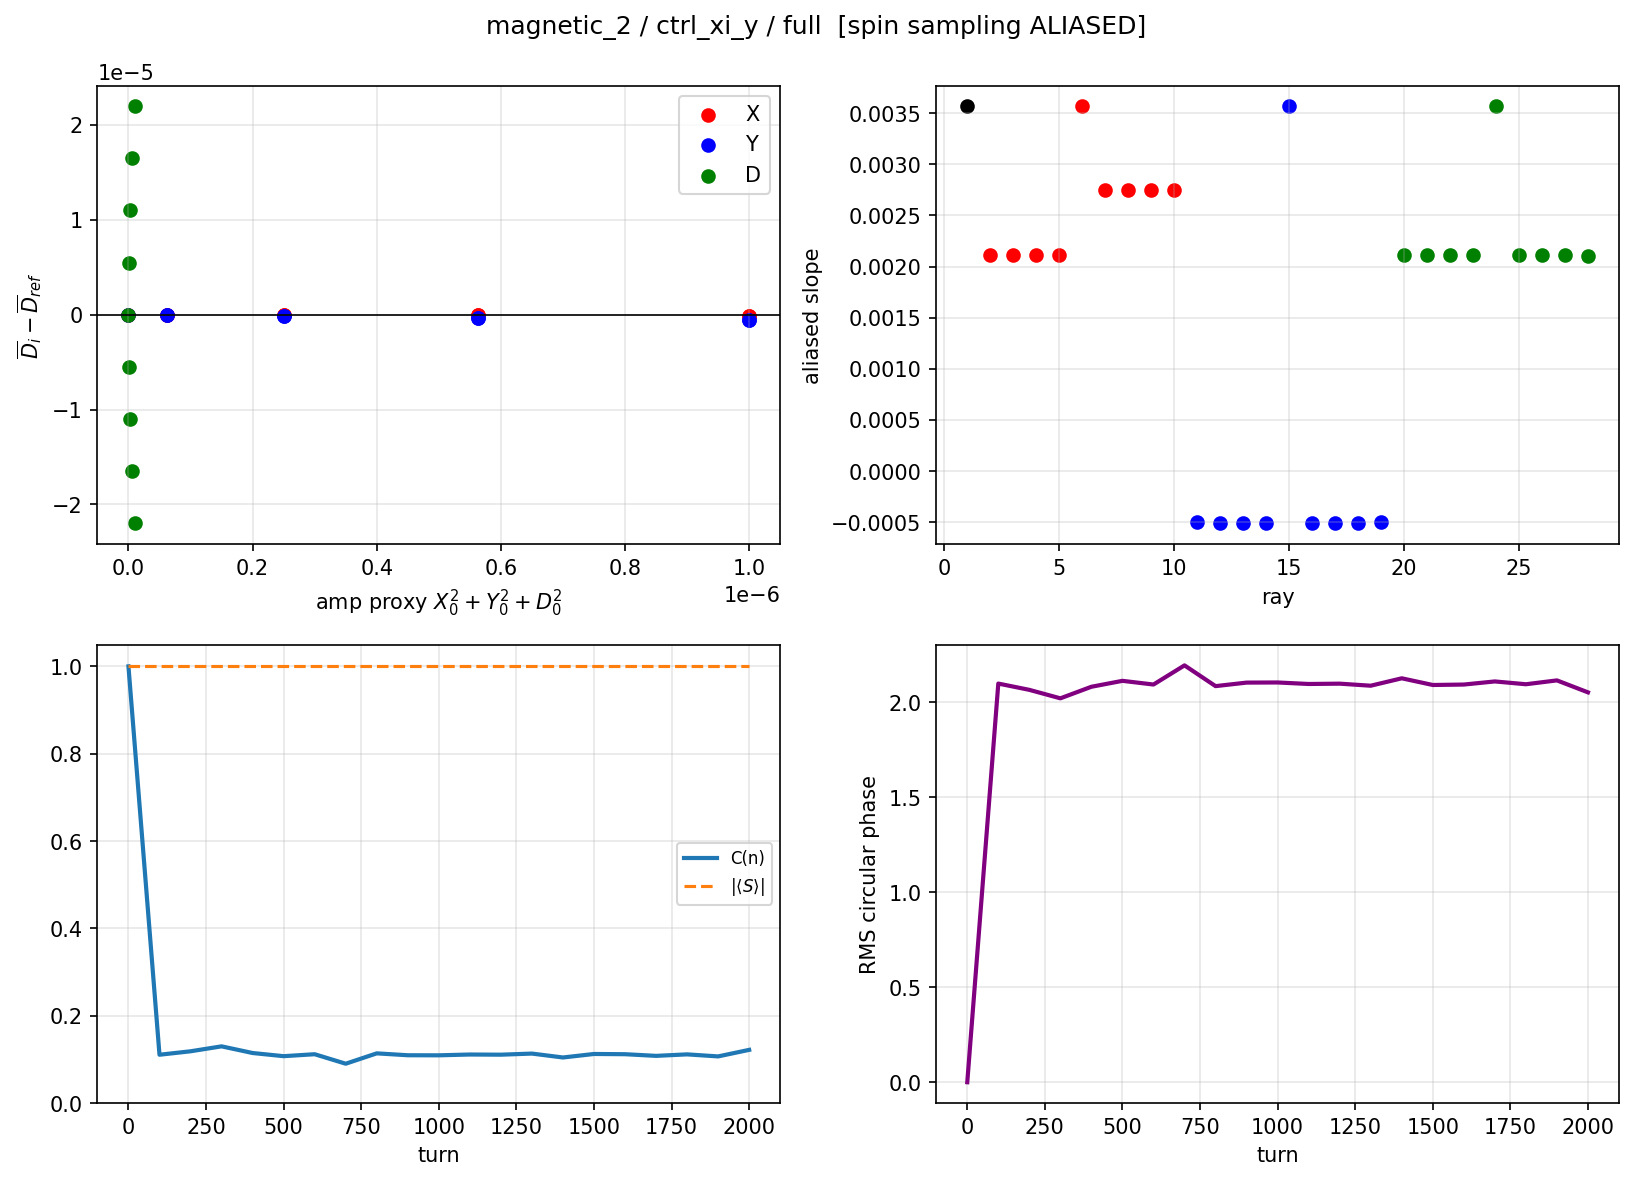

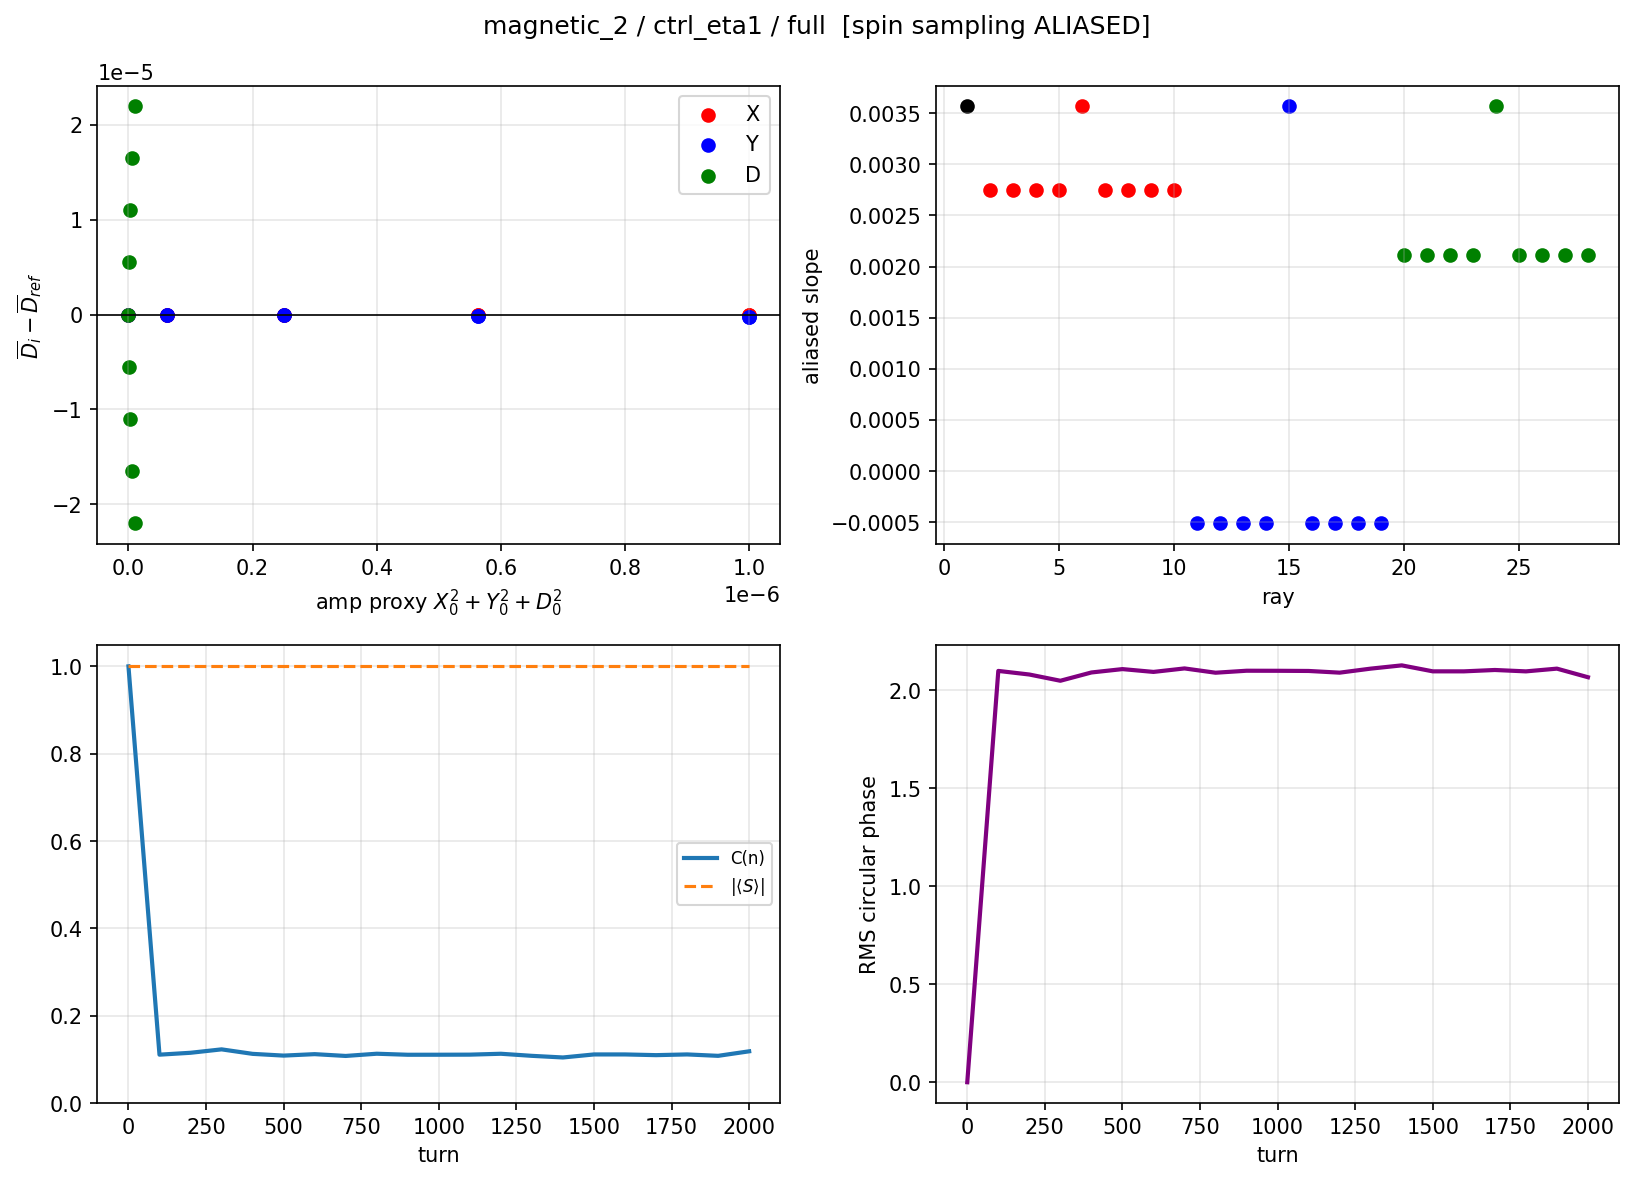

,kind,tag,aliased,dn_save,C_final,pol_final,RMS_D_X,RMS_D_Y,RMS_D_D,dnu_rms
0,full,natural,True,100.0,0.110307,1.0,0.0,0.0,0.000014,None
1,full,Istar,True,100.0,0.111498,1.0,0.0,0.0,0.000014,None
2,full,ctrl_xi_x,True,100.0,0.121860,1.0,0.0,0.0,0.000014,None
3,full,ctrl_xi_y,True,100.0,0.121860,1.0,0.0,0.0,0.000014,None
4,full,ctrl_eta1,True,100.0,0.118552,1.0,0.0,0.0,0.000014,None


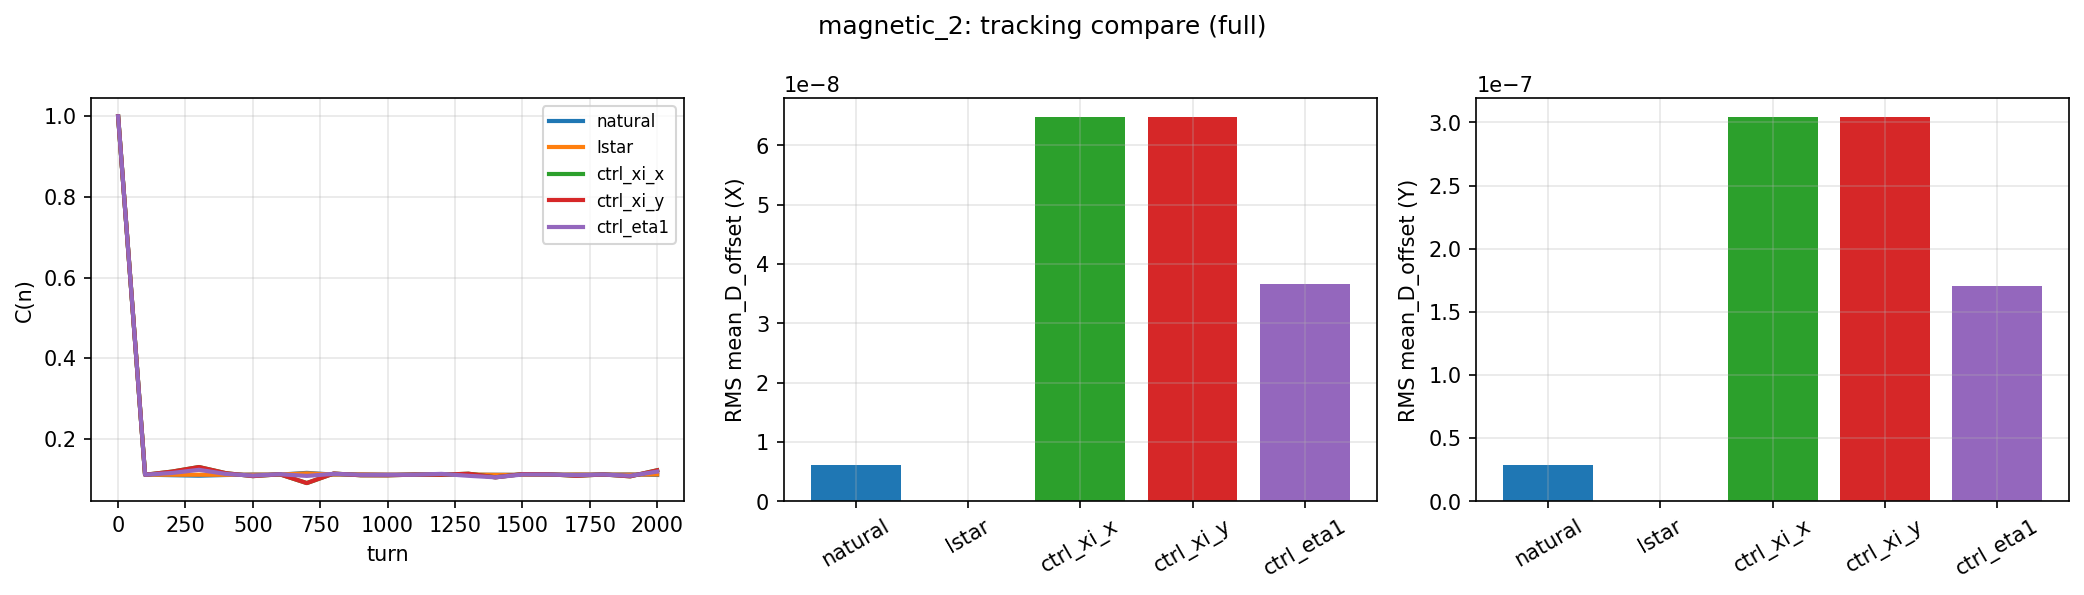

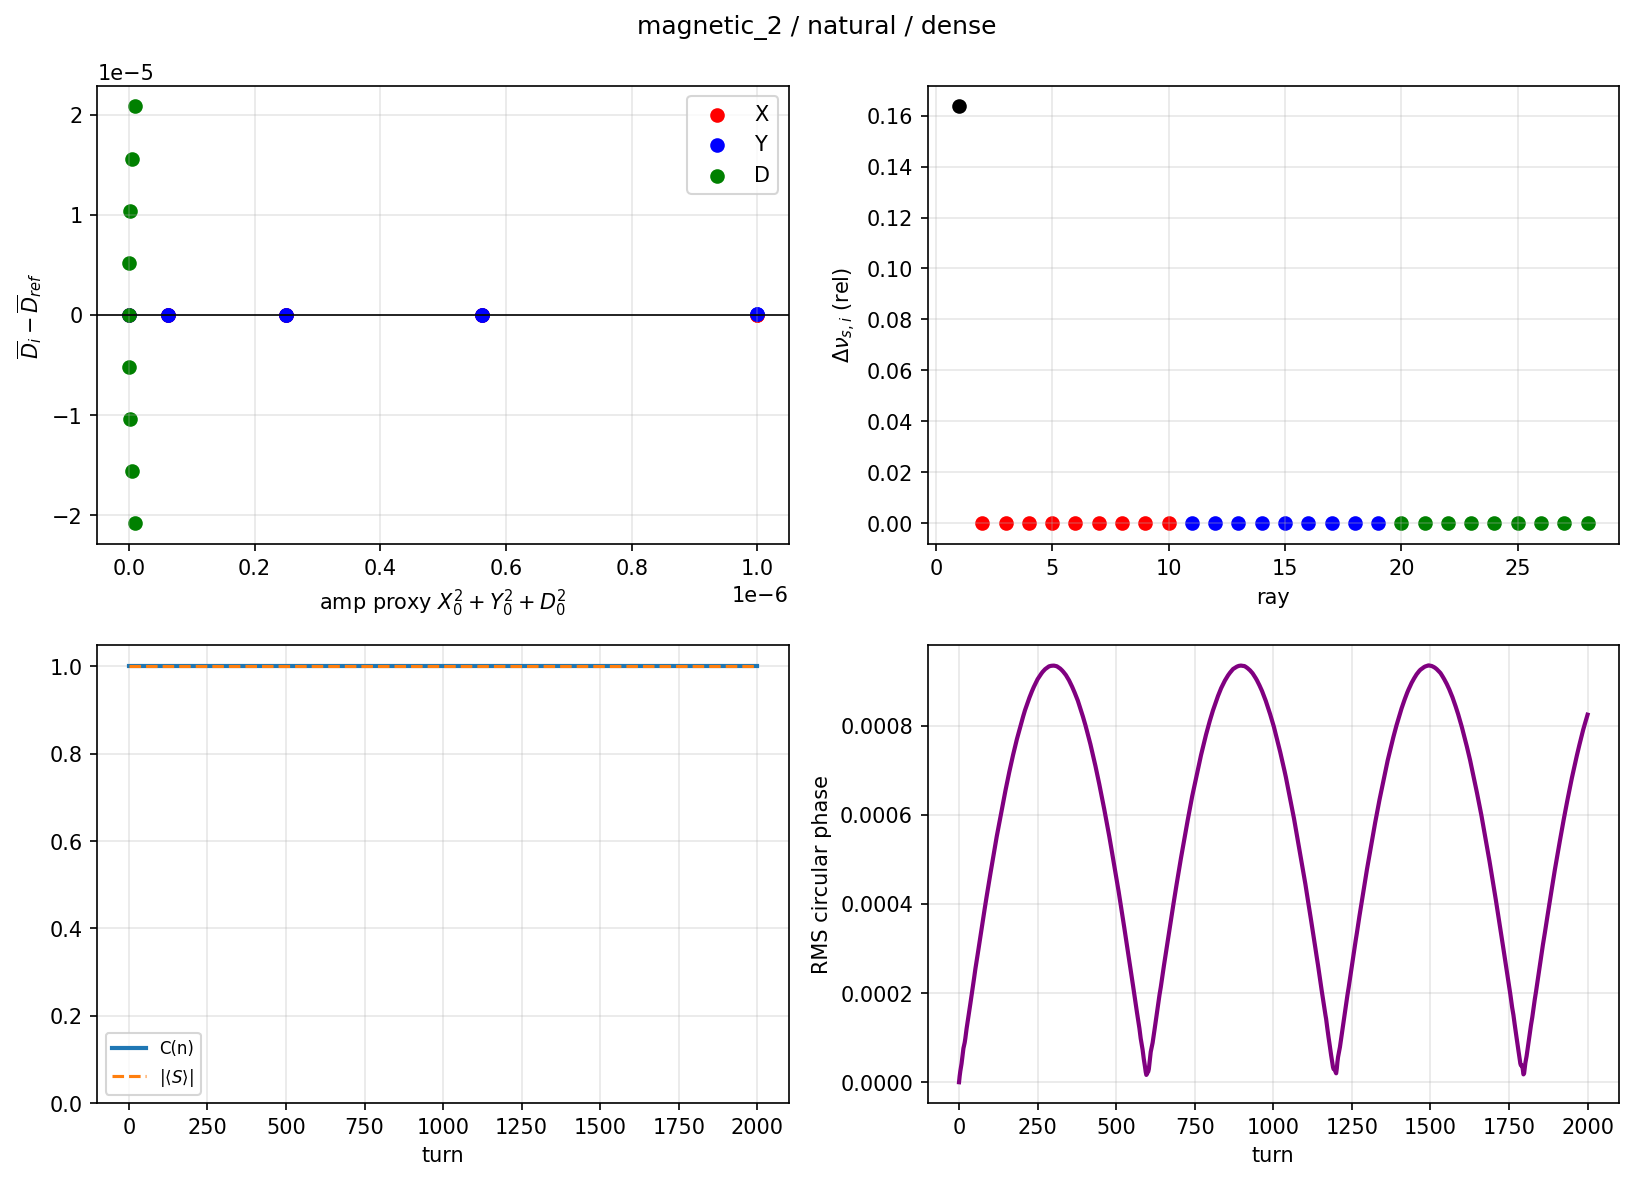

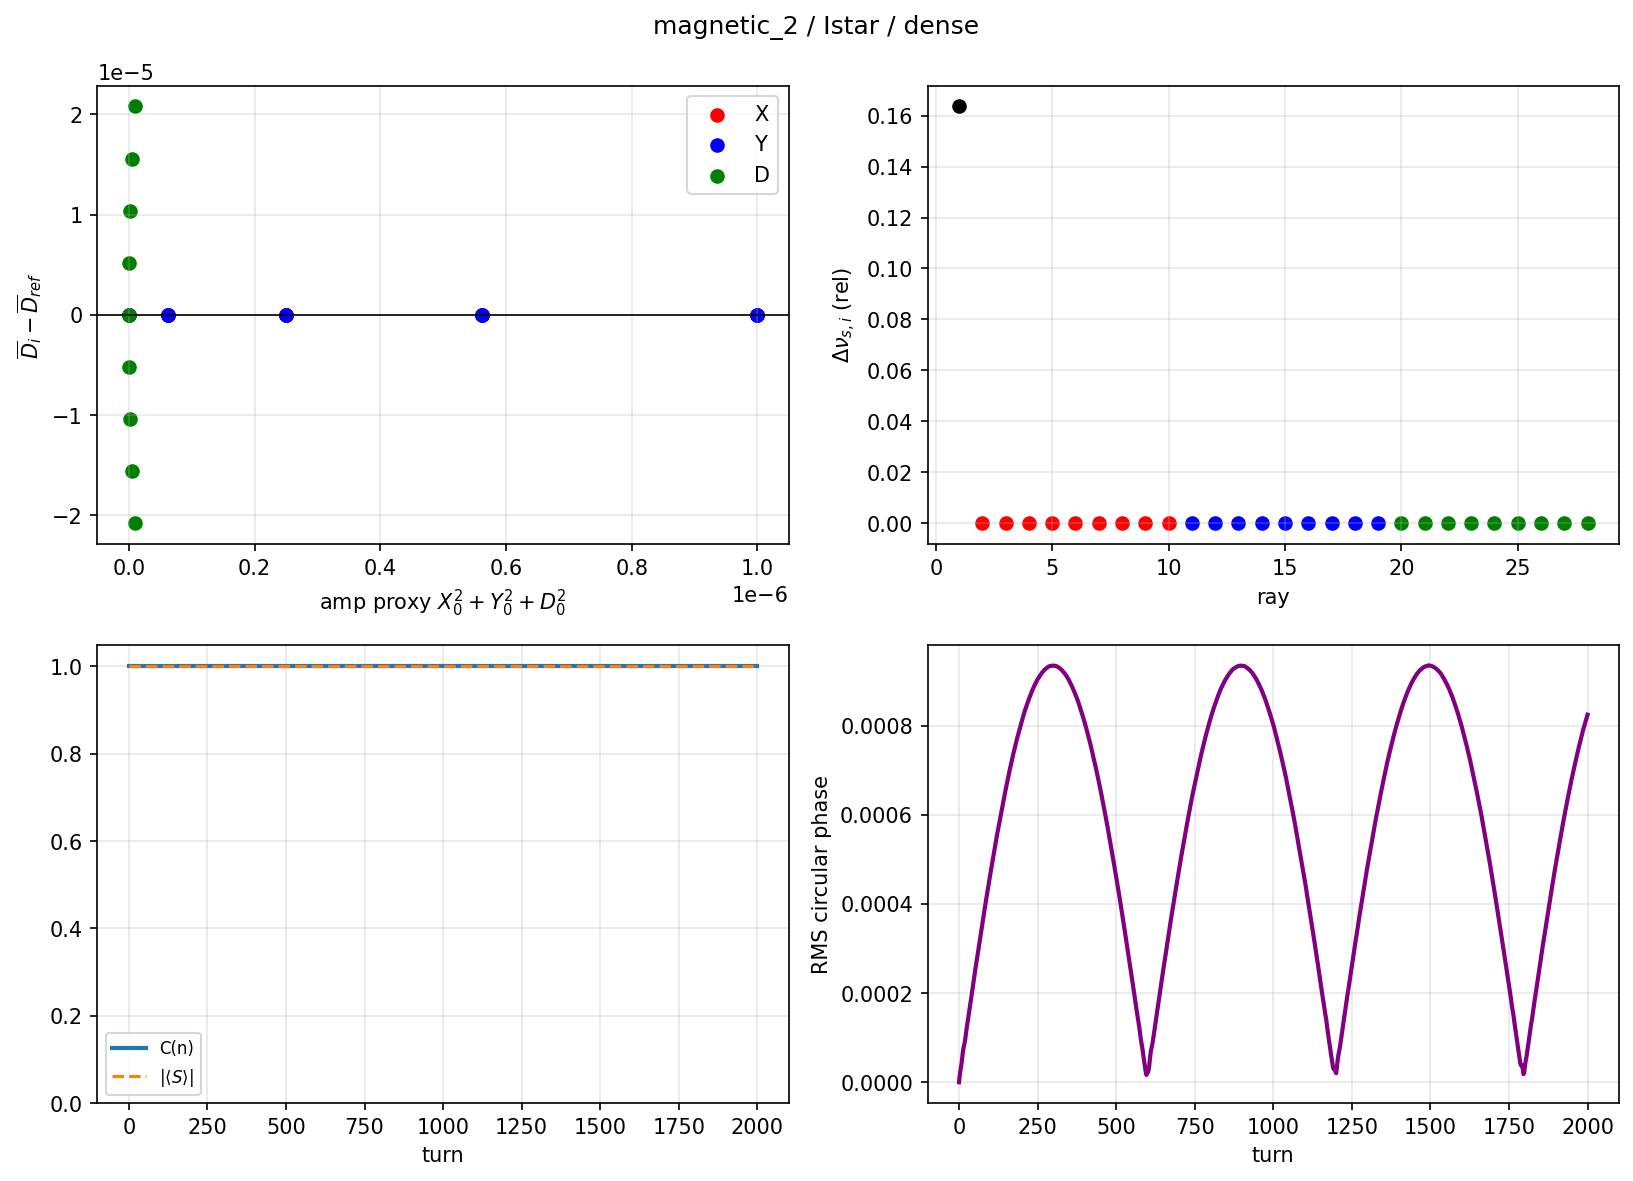

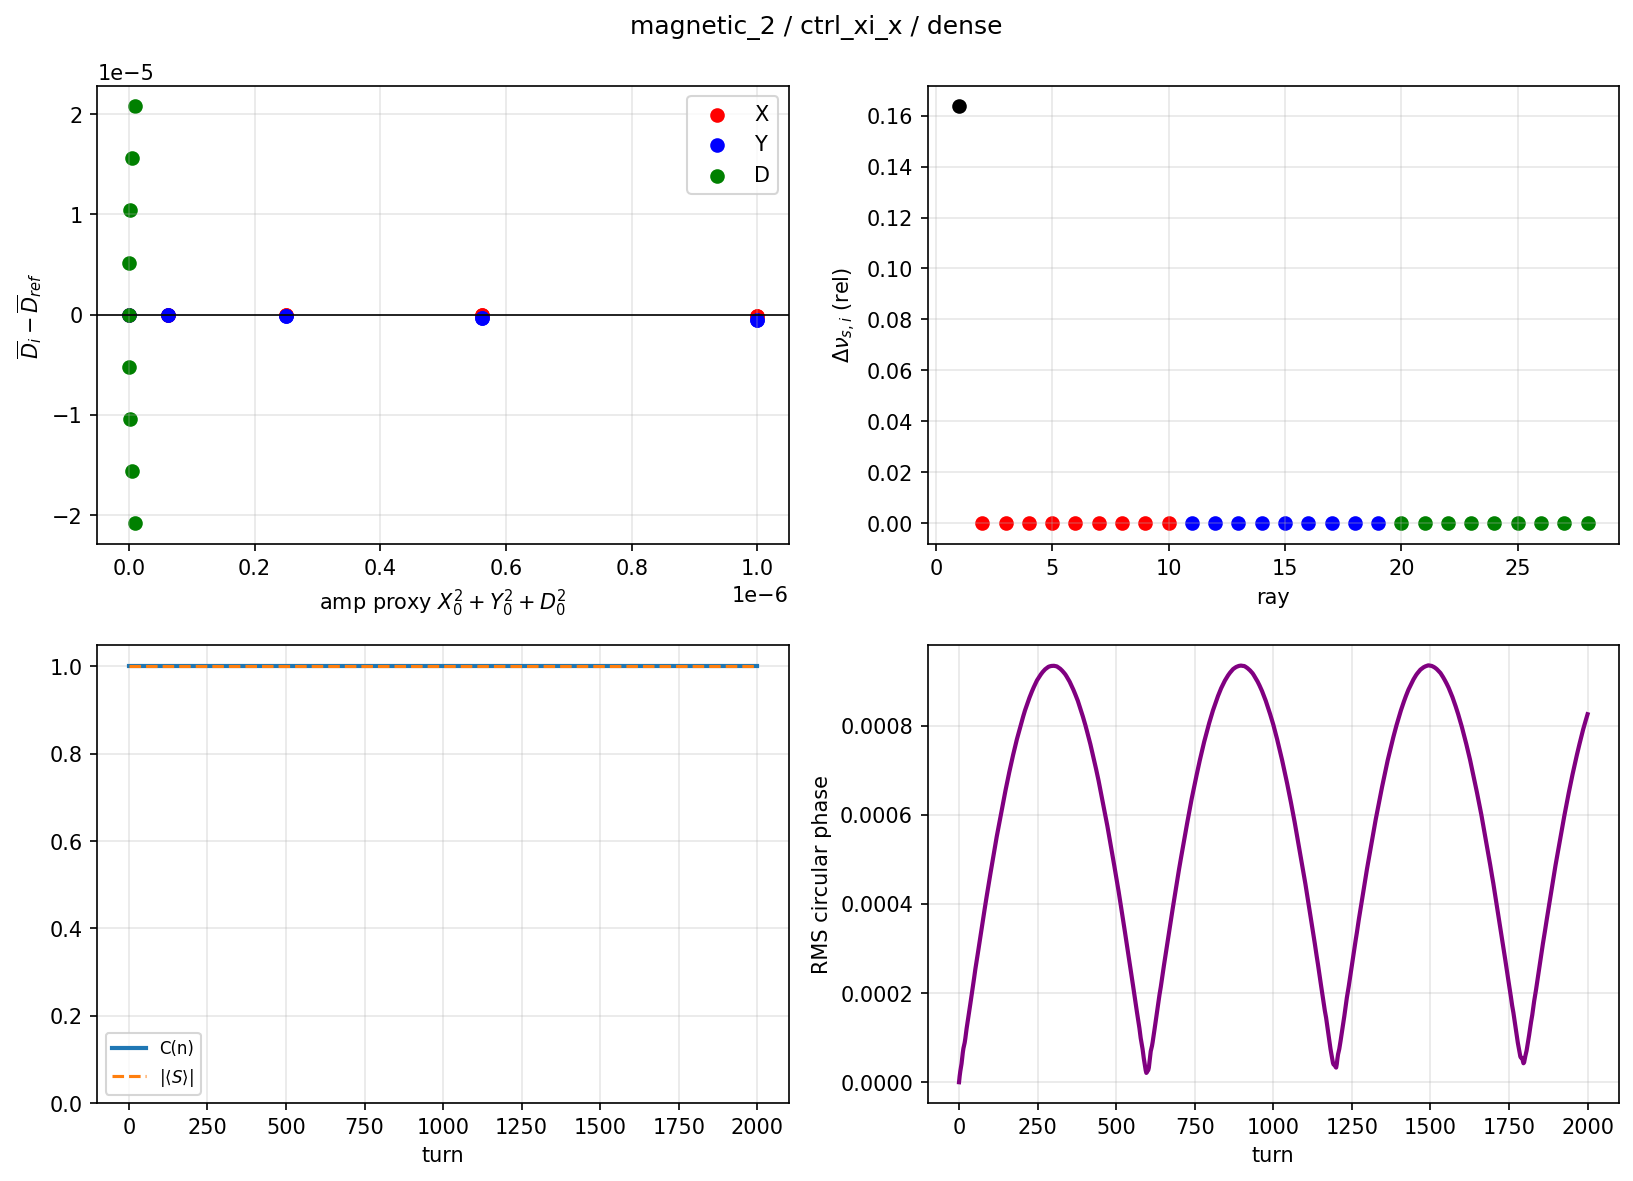

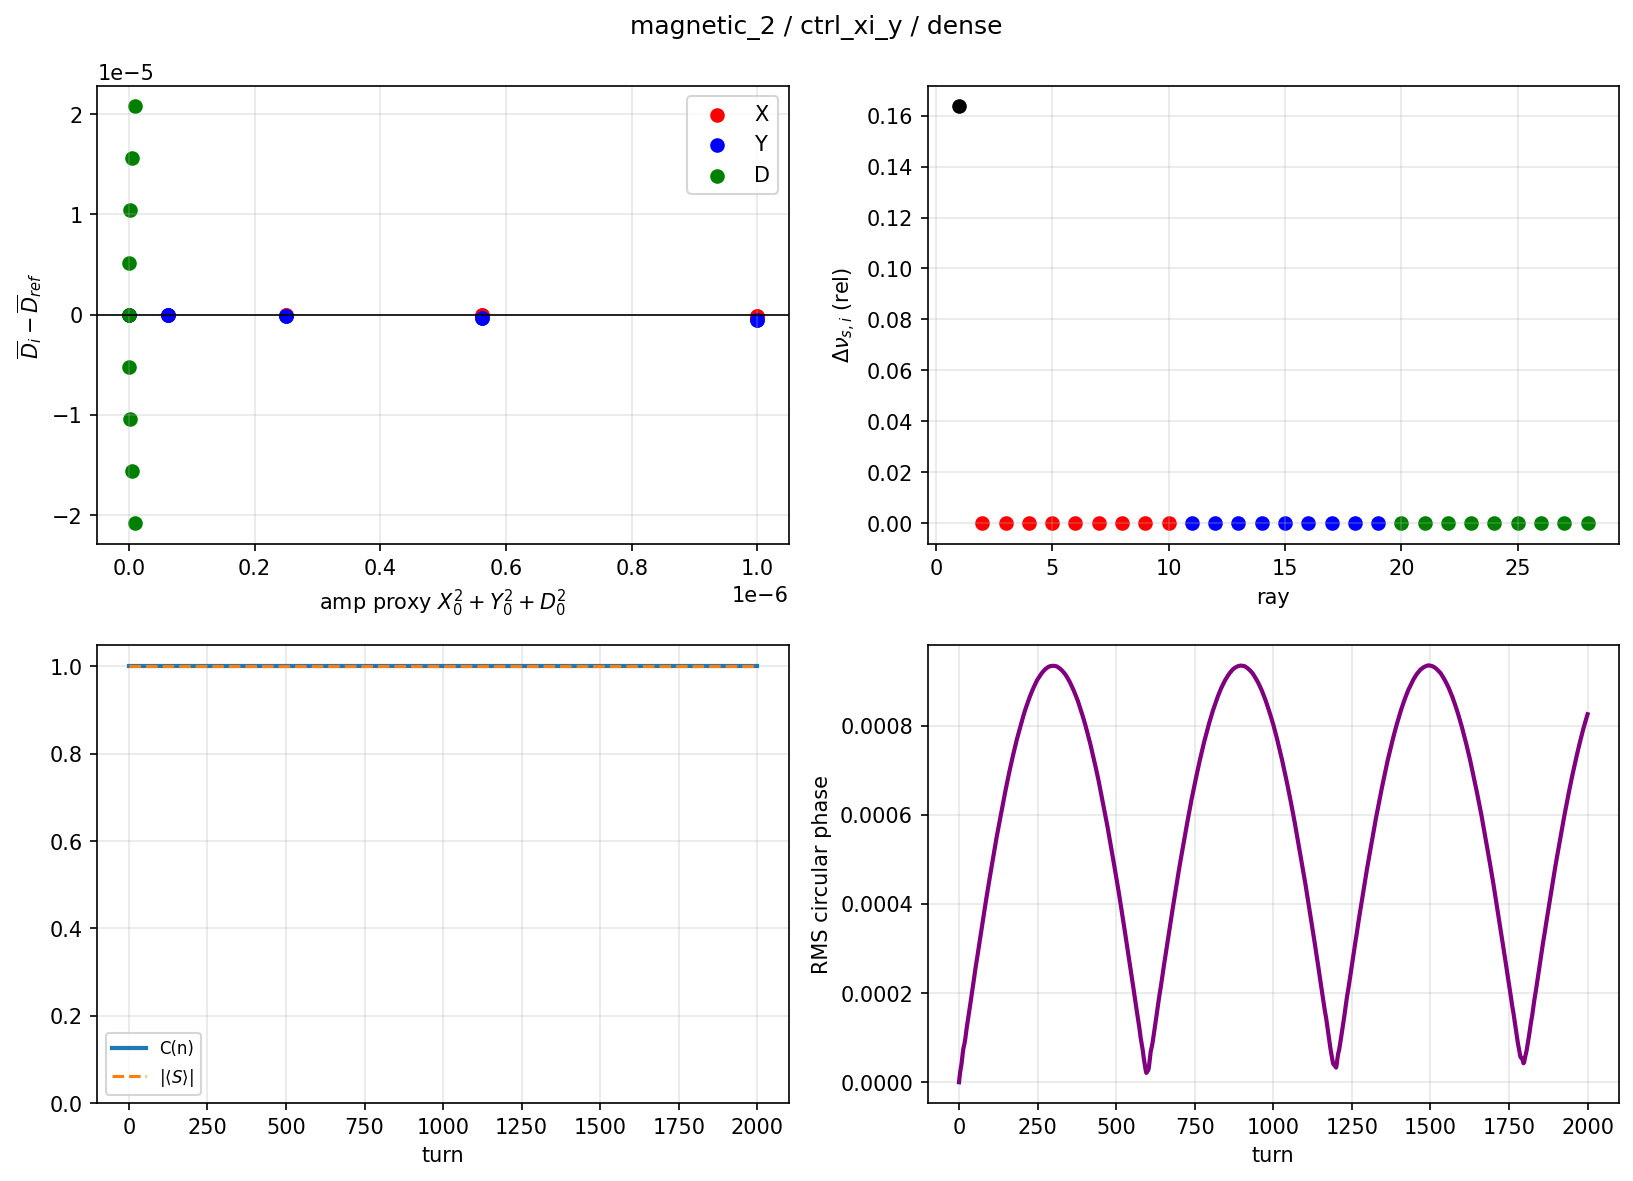

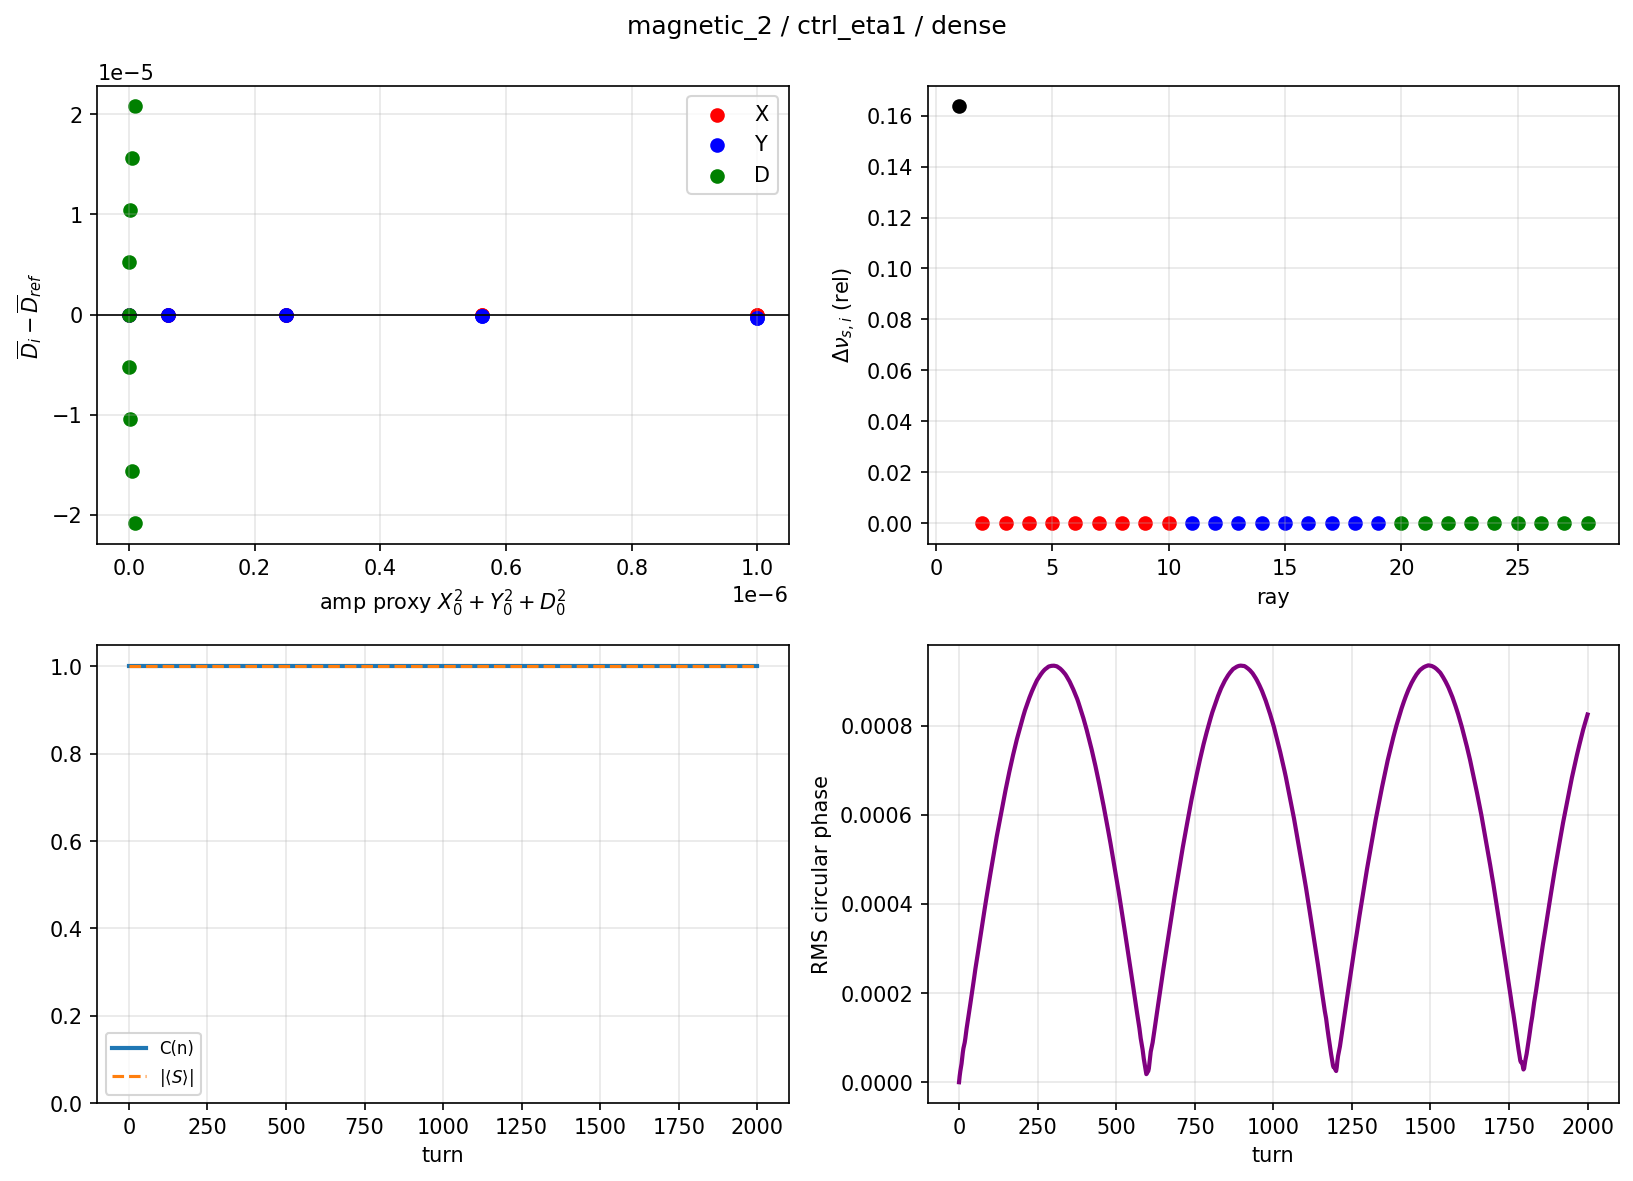

,kind,tag,aliased,dn_save,C_final,pol_final,RMS_D_X,RMS_D_Y,RMS_D_D,dnu_rms
0,dense,natural,False,2.0,1.0,1.0,0.0,0.0,0.000013,0.0
1,dense,Istar,False,2.0,1.0,1.0,0.0,0.0,0.000013,0.0
2,dense,ctrl_xi_x,False,2.0,1.0,1.0,0.0,0.0,0.000013,0.0
3,dense,ctrl_xi_y,False,2.0,1.0,1.0,0.0,0.0,0.000013,0.0
4,dense,ctrl_eta1,False,2.0,1.0,1.0,0.0,0.0,0.000013,0.0


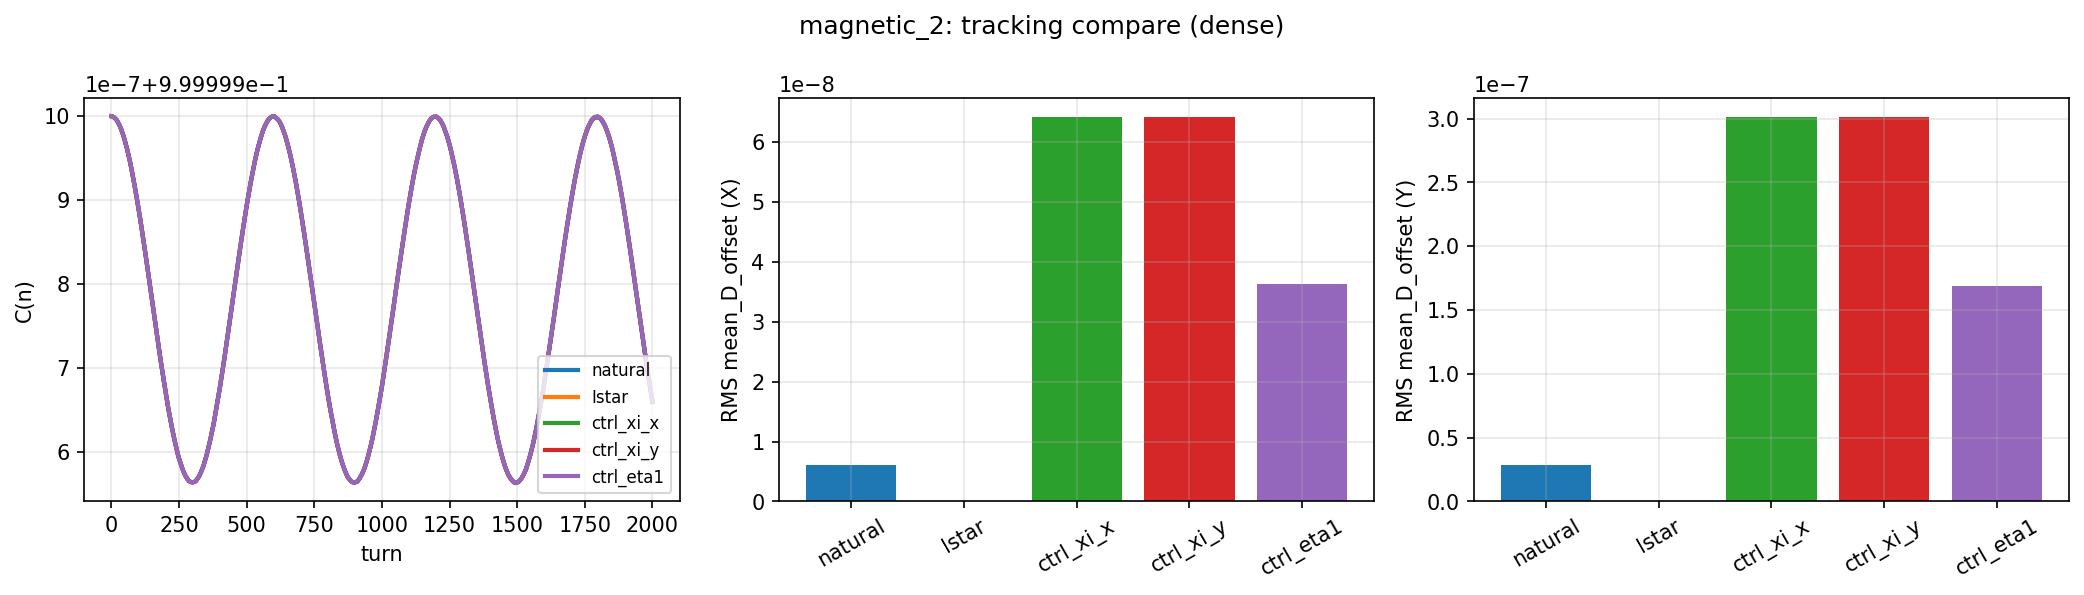

In [11]:
pilot = cfg["tracking"]["pilot_stem"]
tags = ["natural", "Istar", "ctrl_xi_x", "ctrl_xi_y", "ctrl_eta1"]

def load_analyses(kind):
    out = {}
    for tag in tags:
        path = DAT_OUT / pilot / f"track_{tag}_{kind}_analysis.json"
        if path.is_file():
            out[tag] = json.loads(path.read_text(encoding="utf-8"))
    return out

for kind in ("full", "dense"):
    analyses = load_analyses(kind)
    if not analyses:
        print(f"no {kind} analyses yet")
        continue
    rows = []
    for tag, data in analyses.items():
        rows.append({
            "kind": kind,
            "tag": tag,
            "aliased": data["sampling"]["spin_aliased"],
            "dn_save": data["sampling"]["save_interval_turns"],
            "C_final": data.get("C_final"),
            "pol_final": data.get("polarization_final"),
            "RMS_D_X": (data.get("mean_D_offset_rms_by_group") or {}).get("X"),
            "RMS_D_Y": (data.get("mean_D_offset_rms_by_group") or {}).get("Y"),
            "RMS_D_D": (data.get("mean_D_offset_rms_by_group") or {}).get("D"),
            "dnu_rms": data.get("dnu_rms"),
        })
        p = PLOTS / f"{pilot}_track_{tag}_{kind}.png"
        if p.is_file():
            display(Image(filename=str(p)))
    display(pd.DataFrame(rows).round(6))
    pc = PLOTS / f"{pilot}_track_compare_{kind}.png"
    if pc.is_file():
        display(Image(filename=str(pc)))


## 7. Физический итог и следующий тест

**Установлено.** Линейная модель находит $\mathbf I^*$, а отдельный COSY validate даёт $\xi_x$, $\xi_y$, $\eta_1\sim10^{-12}$. В multi-turn `mean_D_offset` для X/Y при $I^*$ падает примерно на четыре порядка. Это согласуется с механизмом подавления поперечного вклада в $\Delta\delta_{eq}$. D-группа почти не меняется: это ожидаемо, поскольку обнуление хроматичностей не убирает само synchrotron-движение.

**Исправлено в spin-диагностике.** Dense ($\Delta n=2$, `psi=0`) даёт $\nu_s^{\rm ref}=0.16356483=|\gamma G|$ и снимает временной алиасинг. Старый sparse анализ с вертикальным спином нельзя использовать: $C\sim10^{-3}$ там был артефактом неподходящей плоскости фазы и редкой дискретизации, а не установленной декогеренцией.

**Что означают текущие dense результаты.** На 2000 оборотах и на данном диагностическом ансамбле $C(n)\approx1$, $|\langle\mathbf S\rangle|\approx1$, относительные $\Delta\nu_s$ малы для всех tag. Это не доказательство отсутствия SCT: эффект ещё не разрешён при выбранных амплитудах и времени.

Следующий физически содержательный тест: matched 6D ансамбль с заданными эмиттансами и $\sigma_\delta$, более длинный dense-трекинг, согласование `fACCLEN` с геометрической $L$, извлечение $Q_s$ из RF map и спектральный анализ спина у линий из resonance scan.